In [3]:
# ============================================
# SETUP
# ============================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
 
from pandas_datareader import data as web
import yfinance as yf
 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import adjusted_rand_score
 
from scipy.optimize import minimize
from arch import arch_model
 
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.expand_frame_repr", False)
 
start           = "2006-03-01"
end             = "2026-12-31"
split_date      = "2022-01-01"
TC_BPS          = 10                    # transaction cost in basis points
N_CLUSTERS_LIST = [2, 3, 4, 5]
 
 
# ============================================
# LOAD FRED DATA FROM LOCAL CSV FILES
# ============================================
 
fred_files = {
    "WTI":          "MCOILWTICO.csv",
    "GAS":          "MHHNGSP.csv",
    "ENERGY_CPI":   "CPIENGSL.csv",
    "FIN_STRESS":   "STLFSI4.csv",
    "BANK_LENDING": "DRTSCILM.csv",
    "WUI":          "WUIGLOBALWEIGHTAVG.csv",
    "WUPI":         "WUPI.csv"
}
 
data = []
for name, file in fred_files.items():
    df = pd.read_csv(file, parse_dates=["observation_date"])
    df = df.set_index("observation_date")
    df = df.rename(columns={df.columns[0]: name})
    data.append(df)
 
macro_raw = pd.concat(data, axis=1).sort_index().loc[start:end]
 
 
# ============================================
# MONTHLY FREQUENCY
# ============================================
 
macro_monthly = pd.DataFrame()
macro_monthly["WTI"]          = macro_raw["WTI"].resample("M").last()
macro_monthly["GAS"]          = macro_raw["GAS"].resample("M").last()
macro_monthly["ENERGY_CPI"]   = macro_raw["ENERGY_CPI"].resample("M").last()
macro_monthly["FIN_STRESS"]   = macro_raw["FIN_STRESS"].resample("M").mean()
macro_monthly["BANK_LENDING"] = macro_raw["BANK_LENDING"].resample("M").last().ffill()
macro_monthly["WUI"]          = macro_raw["WUI"].resample("M").last().ffill()
macro_monthly["WUPI"]         = macro_raw["WUPI"].resample("M").last().ffill()
 
 
# ============================================
# MACRO TRANSFORMATIONS
# ============================================
 
macro = pd.DataFrame(index=macro_monthly.index)
macro["WTI_MOM"]        = macro_monthly["WTI"].pct_change(1) * 100
macro["GAS_MOM"]        = macro_monthly["GAS"].pct_change(1) * 100
macro["ENERGY_CPI_MOM"] = macro_monthly["ENERGY_CPI"].pct_change(1) * 100
macro["FIN_STRESS"]     = macro_monthly["FIN_STRESS"]
macro["BANK_LENDING"]   = macro_monthly["BANK_LENDING"]
macro["WUI"]            = macro_monthly["WUI"]
macro["WUPI"]           = macro_monthly["WUPI"]
 
 
# ============================================
# GPR
# ============================================
 
gpr_raw = pd.read_excel("data_gpr_export.xls")
gpr = gpr_raw.iloc[:, [0, 1]].copy()
gpr.columns = ["DATE", "GPR"]
gpr["DATE"] = pd.to_datetime(gpr["DATE"])
gpr = gpr.set_index("DATE").loc["2000-01-01":]
gpr.index = gpr.index.to_period("M").to_timestamp("M")
macro["GPR"] = gpr["GPR"]
 
 
# ============================================
# GSCPI
# ============================================
 
gscpi_url = "https://www.newyorkfed.org/medialibrary/research/interactives/gscpi/downloads/gscpi_data.xlsx"
gscpi_raw = pd.read_excel(gscpi_url, sheet_name="GSCPI Monthly Data", skiprows=5)
gscpi = gscpi_raw.rename(columns={gscpi_raw.columns[0]: "DATE", gscpi_raw.columns[1]: "GSCPI"})
gscpi = gscpi[["DATE", "GSCPI"]]
gscpi["DATE"] = pd.to_datetime(gscpi["DATE"])
gscpi = gscpi.set_index("DATE").loc["2000-01-01":]
gscpi.index = gscpi.index.to_period("M").to_timestamp("M")
macro["GSCPI"] = gscpi["GSCPI"]
 
macro = macro.dropna()
 

In [4]:
# ============================================
# TRAIN / TEST SPLIT + SCALING
# ============================================
 
macro_train = macro.loc[macro.index < split_date].copy()
macro_test  = macro.loc[macro.index >= split_date].copy()
 
scaler = StandardScaler()
macro_train_scaled = pd.DataFrame(
    scaler.fit_transform(macro_train),
    columns=macro_train.columns, index=macro_train.index
)
macro_test_scaled = pd.DataFrame(
    scaler.transform(macro_test),
    columns=macro_test.columns, index=macro_test.index
)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


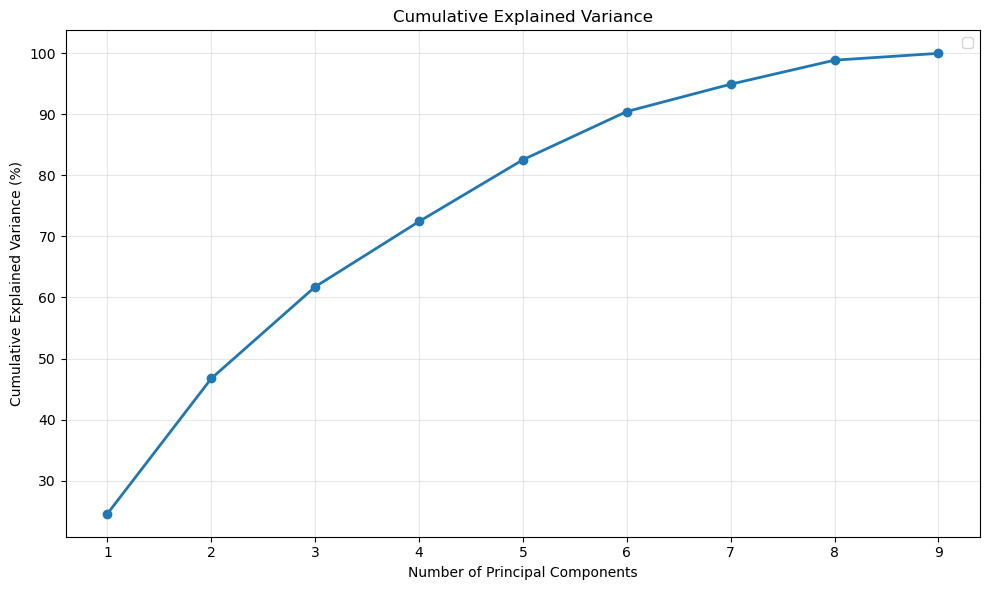

In [5]:
# ============================================
# PCA
# ============================================
 
PC_COLS = ["PC1", "PC2", "PC3", "PC4", "PC5", "PC6"]
 
pca = PCA()
pca.fit(macro_train_scaled)
 
pca_train = pd.DataFrame(
    pca.transform(macro_train_scaled),
    columns=[f"PC{i+1}" for i in range(macro_train_scaled.shape[1])],
    index=macro_train_scaled.index
)[PC_COLS]
 
pca_test = pd.DataFrame(
    pca.transform(macro_test_scaled),
    columns=[f"PC{i+1}" for i in range(macro_test_scaled.shape[1])],
    index=macro_test_scaled.index
)[PC_COLS]
 
# --- Cumulative explained variance plot ---
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumvar) + 1), cumvar, marker="o", linewidth=2)
plt.xticks(range(1, len(cumvar) + 1))
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("Cumulative Explained Variance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
# ============================================
# FINANCIAL DATA
# ============================================
 
tickers = ["SPY", "QQQ", "VGK", "EEM", "TLT", "GLD", "DBC", "BIL"]
 
prices        = yf.download(tickers, start="2000-01-01", auto_adjust=True)["Close"].dropna()
returns_daily = prices.pct_change().dropna()
asset_names   = prices.columns.tolist()
risky_assets  = [a for a in asset_names if a != "BIL"]


[*********************100%***********************]  8 of 8 completed


In [7]:
# ============================================
# HELPER FUNCTIONS
# ============================================
 
def max_sharpe_ratio(mu, cov_matrix, rf, max_weight=1):
    n = len(mu)
    def neg_sharpe(w):
        ret = w @ mu.values
        vol = np.sqrt(w @ cov_matrix.values @ w)
        return -(ret - rf) / vol
    result = minimize(
        neg_sharpe,
        np.repeat(1/n, n),
        method="SLSQP",
        bounds=[(0, max_weight)] * n,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1}
    )
    return result.x
 
 
def mean_variance_optimization(mu, cov_matrix, risk_aversion=10, max_weight=1):
    n = len(mu)
    def neg_utility(w):
        ret = w @ mu.values
        var = w @ cov_matrix.values @ w
        return -(ret - (risk_aversion / 2) * var)
    result = minimize(
        neg_utility,
        np.repeat(1/n, n),
        method="SLSQP",
        bounds=[(0, max_weight)] * n,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1}
    )
    return result.x
 
 
def performance_metrics(returns, rf_daily, benchmark_returns=None, alpha_95=0.05, alpha_99=0.01):
    returns  = returns.dropna()
    rf_daily = rf_daily.reindex(returns.index).dropna()
    returns  = returns.reindex(rf_daily.index)
 
    ann_return = returns.mean() * 252
    ann_vol    = returns.std() * np.sqrt(252)
    rf_annual  = rf_daily.mean() * 252
    sharpe     = (ann_return - rf_annual) / ann_vol
 
    cumulative   = (1 + returns).cumprod()
    max_drawdown = (cumulative / cumulative.cummax() - 1).min()
    calmar       = ann_return / abs(max_drawdown)
 
    var95 = returns.quantile(alpha_95)
    var99 = returns.quantile(alpha_99)
    es95  = returns[returns <= var95].mean()
    es99  = returns[returns <= var99].mean()
 
    alpha_ann = beta = alpha_tstat = r_squared = np.nan
 
    if benchmark_returns is not None:
        benchmark_returns = benchmark_returns.reindex(returns.index).dropna()
        common_idx = returns.index.intersection(benchmark_returns.index).intersection(rf_daily.index)
 
        y = returns.loc[common_idx] - rf_daily.loc[common_idx]
        x = benchmark_returns.loc[common_idx] - rf_daily.loc[common_idx]
 
        X = sm.add_constant(pd.DataFrame({"Market": x}))
        capm_model = sm.OLS(y, X).fit()
 
        alpha_daily = capm_model.params["const"]
        beta        = capm_model.params["Market"]
        alpha_ann   = (1 + alpha_daily) ** 252 - 1
        alpha_tstat = capm_model.tvalues["const"]
        r_squared   = capm_model.rsquared
 
    return pd.Series({
        "Annual Return":     ann_return,
        "Annual Volatility": ann_vol,
        "Risk-Free Rate":    rf_annual,
        "Sharpe Ratio":      sharpe,
        "Alpha Annual":      alpha_ann,
        "Beta vs QQQ":       beta,
        "Alpha t-stat":      alpha_tstat,
        "CAPM R²":           r_squared,
        "VaR 95%":           var95,
        "VaR 99%":           var99,
        "ES 95%":            es95,
        "ES 99%":            es99,
        "Max Drawdown":      max_drawdown,
        "Calmar Ratio":      calmar
    })
 
 
def apply_transaction_costs(portfolio_returns, weights, tc_bps=TC_BPS):
    turnover = weights.diff().abs().sum(axis=1)
    turnover.iloc[0] = weights.iloc[0].abs().sum()
    return portfolio_returns - turnover * (tc_bps / 10_000)
 
 
def plot_stacked_weights(weights_daily, title):
    asset_order = [a for a in ["SPY", "QQQ", "VGK", "EEM", "TLT", "GLD", "DBC"] if a in risky_assets]
    w = weights_daily[asset_order].copy() * 100
    w_monthly = w.resample("M").last()
    w_monthly = w_monthly.div(w_monthly.sum(axis=1), axis=0) * 100
 
    ax = w_monthly.plot(kind="bar", stacked=True, figsize=(16, 6), width=0.90)
    ax.set_ylim(0, 100)
    ax.set_title(title)
    ax.set_ylabel("Portfolio Weight (%)")
    step = max(1, len(w_monthly) // 10)
    ax.set_xticklabels(
        [d.strftime("%Y-%m") if i % step == 0 else "" for i, d in enumerate(w_monthly.index)],
        rotation=45, ha="right"
    )
    ax.legend(title="Asset", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
 

In [8]:
# ============================================
# REGIME MODEL
# ============================================
 
def fit_regime_model(features_train, features_test, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    train_clusters = kmeans.fit_predict(features_train)
    test_clusters  = kmeans.predict(features_test)
 
    lda = LinearDiscriminantAnalysis()
    lda.fit(features_train, train_clusters)
 
    features_all = pd.concat([features_train, features_test]).sort_index()
    regime_probs_all = pd.DataFrame(
        lda.predict_proba(features_all),
        columns=lda.classes_,
        index=features_all.index
    )
 
    return {
        "kmeans":           kmeans,
        "lda":              lda,
        "train_clusters":   train_clusters,
        "test_clusters":    test_clusters,
        "regime_probs_all": regime_probs_all
    }
 
 
# ============================================
# STATIC WEIGHTS
# ============================================
 
def static_regime_weights(train_clusters, features_train):

    monthly_clusters = pd.DataFrame(
        {"cluster": train_clusters},
        index=features_train.index
    )

    monthly_clusters.index = monthly_clusters.index.to_period("M")

    # Ultimo mese realmente disponibile nel training corrente
    last_train_month = features_train.index.max().to_period("M")

    # IMPORTANTE:
    # niente split_date globale.
    # Usa tutti i rendimenti disponibili fino alla fine
    # del training corrente.
    returns_train_full = returns_daily.loc[
        returns_daily.index.to_period("M") <= last_train_month,
        risky_assets + ["BIL"]
    ].copy()

    returns_train_full["month"] = (
        returns_train_full.index.to_period("M")
    )

    returns_with_regime = returns_train_full.merge(
        monthly_clusters,
        left_on="month",
        right_index=True,
        how="left"
    ).dropna()

    regime_weights_sharpe = {}
    regime_weights_mv = {}

    for regime in sorted(
        returns_with_regime["cluster"].unique()
    ):

        subset = returns_with_regime[
            returns_with_regime["cluster"] == regime
        ]

        r = subset[risky_assets]

        if len(r) < 20:
            continue

        mu = r.mean()
        cov = r.cov()
        rf = subset["BIL"].mean()

        regime_weights_sharpe[regime] = (
            max_sharpe_ratio(mu, cov, rf)
        )

        regime_weights_mv[regime] = (
            mean_variance_optimization(mu, cov)
        )

    sharpe_df = pd.DataFrame(
        regime_weights_sharpe,
        index=risky_assets
    ).T.sort_index()

    mv_df = pd.DataFrame(
        regime_weights_mv,
        index=risky_assets
    ).T.sort_index()

    return sharpe_df, mv_df
 
 
# ============================================
# BACKTEST — STATIC WEIGHTS
# ============================================
 
def backtest_static(
    regime_probs_all,
    regime_weights_df,
    start_date=None,
    end_date=None
):

    probs = regime_probs_all.copy()
    probs.index = probs.index.to_period("M")

    # Probabilità del mese precedente
    probs_lagged = probs.shift(1)

    # Default = comportamento originale
    if start_date is None:
        start_date = pd.Timestamp(split_date)
    else:
        start_date = pd.Timestamp(start_date)

    if end_date is not None:
        end_date = pd.Timestamp(end_date)

    mask = returns_daily.index >= start_date

    if end_date is not None:
        mask &= returns_daily.index < end_date

    returns_test = returns_daily.loc[
        mask,
        risky_assets
    ].copy()

    returns_test["month"] = (
        returns_test.index.to_period("M")
    )

    probs_daily = (
        returns_test[["month"]]
        .merge(
            probs_lagged,
            left_on="month",
            right_index=True,
            how="left"
        )
    )

    probs_daily.index = returns_test.index

    probs_daily = (
        probs_daily
        .drop(columns="month")
        .dropna()
    )

    returns_test = returns_test.loc[
        probs_daily.index,
        risky_assets
    ]

    common = regime_weights_df.index.intersection(
        probs_daily.columns
    )

    if len(common) == 0:
        return pd.Series(dtype=float), pd.DataFrame()

    probs_daily = probs_daily[common]

    probs_daily = probs_daily.div(
        probs_daily.sum(axis=1),
        axis=0
    )

    weights = (
        probs_daily
        @ regime_weights_df.loc[common]
    )

    weights.index = returns_test.index

    port_returns = (
        weights * returns_test
    ).sum(axis=1)

    return port_returns, weights
 
 
# ============================================
# BACKTEST — EXPANDING WEIGHTS
# ============================================
 
def backtest_expanding(features_train, features_test, train_clusters, test_clusters, lda, regime_probs_all):
    monthly_clusters_all = pd.concat([
        pd.DataFrame({"cluster": train_clusters}, index=features_train.index),
        pd.DataFrame({"cluster": test_clusters},  index=features_test.index)
    ]).sort_index()
    monthly_clusters_all.index = monthly_clusters_all.index.to_period("M")
 
    probs_all = regime_probs_all.copy()
    probs_all.index = probs_all.index.to_period("M")
    probs_all_lagged = probs_all.shift(1)
 
    test_months = features_test.index.to_period("M").unique().sort_values()
 
    weights_list_sharpe = []
    weights_list_mv     = []
 
    for current_month in test_months:
        available_clusters = monthly_clusters_all.loc[
            monthly_clusters_all.index < current_month
        ]
        hist_returns = returns_daily.loc[
            returns_daily.index.to_period("M") < current_month,
            risky_assets + ["BIL"]
        ].copy()
        hist_returns["month"] = hist_returns.index.to_period("M")
        hist_with_regime = hist_returns.merge(
            available_clusters, left_on="month", right_index=True, how="left"
        ).dropna()
 
        regime_w_sharpe = {}
        regime_w_mv     = {}
 
        for regime in sorted(hist_with_regime["cluster"].unique()):
            subset = hist_with_regime[hist_with_regime["cluster"] == regime]
            r = subset[risky_assets]
            if len(r) < 20:
                continue
            mu  = r.mean()
            cov = r.cov()
            rf  = subset["BIL"].mean()
            regime_w_sharpe[regime] = max_sharpe_ratio(mu, cov, rf)
            regime_w_mv[regime]     = mean_variance_optimization(mu, cov)
 
        sharpe_df = pd.DataFrame(regime_w_sharpe, index=risky_assets).T.sort_index()
        mv_df     = pd.DataFrame(regime_w_mv,     index=risky_assets).T.sort_index()
 
        probs_month = probs_all_lagged.loc[current_month]
        days_month  = returns_daily.loc[
            returns_daily.index.to_period("M") == current_month
        ].index
 
        for w_list, df in [(weights_list_sharpe, sharpe_df), (weights_list_mv, mv_df)]:
            common  = df.index.intersection(probs_month.index)
            probs   = probs_month.loc[common]
            probs   = probs / probs.sum()
            w_month = probs @ df.loc[common]
            w_daily = pd.DataFrame(
                np.tile(w_month.values, (len(days_month), 1)),
                index=days_month, columns=risky_assets
            )
            w_list.append(w_daily)
 
    weights_sharpe = pd.concat(weights_list_sharpe).sort_index()
    weights_mv     = pd.concat(weights_list_mv).sort_index()
 
    ret_assets     = returns_daily.loc[weights_sharpe.index, risky_assets]
    returns_sharpe = (weights_sharpe * ret_assets).sum(axis=1)
    returns_mv     = (weights_mv     * ret_assets).sum(axis=1)
 
    return returns_sharpe, weights_sharpe, returns_mv, weights_mv
 

In [9]:
# ============================================
# FEATURE SETS
# ============================================
 
feature_sets = {
    "PCA": {"train": pca_train.copy(),          "test": pca_test.copy()},
    "RAW": {"train": macro_train_scaled.copy(), "test": macro_test_scaled.copy()}
}

In [10]:
# ============================================
# MAIN LOOP
# ============================================
 
all_returns = {}
all_weights = {}
 
for feature_name, feature_data in feature_sets.items():
    features_train = feature_data["train"]
    features_test  = feature_data["test"]
 
    for n_clusters in N_CLUSTERS_LIST:
        print(f"Running {feature_name} | K={n_clusters}")
 
        model = fit_regime_model(features_train, features_test, n_clusters)
 
        regime_probs_all = model["regime_probs_all"]
        train_clusters   = model["train_clusters"]
        test_clusters    = model["test_clusters"]
 
        # --- Static ---
        static_sharpe_w, static_mv_w = static_regime_weights(train_clusters, features_train)
 
        static_sharpe_ret, static_sharpe_wts = backtest_static(regime_probs_all, static_sharpe_w)
        static_mv_ret,     static_mv_wts     = backtest_static(regime_probs_all, static_mv_w)
 
        # --- Expanding ---
        (exp_sharpe_ret, exp_sharpe_wts,
         exp_mv_ret,     exp_mv_wts) = backtest_expanding(
            features_train, features_test,
            train_clusters, test_clusters,
            model["lda"], regime_probs_all
        )
 
        # --- Apply transaction costs (net returns) ---
        strategies = {
            "Static_Max_Sharpe":       (static_sharpe_ret, static_sharpe_wts),
            "Static_Mean_Variance":    (static_mv_ret,     static_mv_wts),
            "Expanding_Max_Sharpe":    (exp_sharpe_ret,    exp_sharpe_wts),
            "Expanding_Mean_Variance": (exp_mv_ret,        exp_mv_wts),
        }
 
        for strat_name, (gross_ret, wts) in strategies.items():
            net_ret = apply_transaction_costs(gross_ret, wts)
            key = f"{feature_name}_K{n_clusters}_{strat_name}"
            all_returns[key] = net_ret
            all_weights[key] = wts
 

Running PCA | K=2
Running PCA | K=3
Running PCA | K=4
Running PCA | K=5
Running RAW | K=2
Running RAW | K=3
Running RAW | K=4
Running RAW | K=5


In [11]:
# ============================================
# BENCHMARKS
# ============================================
 
test_index = next(iter(all_returns.values())).index

# --- Equal Weight benchmark ---
equal_weight_w = pd.DataFrame(
    1 / len(risky_assets),
    index=test_index,
    columns=risky_assets
)

equal_weight_gross = (
    returns_daily.loc[test_index, risky_assets] * equal_weight_w
).sum(axis=1)

equal_weight_returns = apply_transaction_costs(
    equal_weight_gross,
    equal_weight_w
) 

# --- Market Benchmark ---
spy_returns          = returns_daily.loc[test_index, "SPY"]
qqq_returns          = returns_daily.loc[test_index, "QQQ"]
 
# --- No-clustering benchmarks (Max Sharpe & Mean-Variance) ---
# Estimated on training data, applied out-of-sample.
# Isolates the contribution of clustering vs. pure portfolio optimization.
 
returns_train_bm = returns_daily.loc[
    returns_daily.index < split_date, risky_assets + ["BIL"]
].copy()
 
mu_bm  = returns_train_bm[risky_assets].mean()
cov_bm = returns_train_bm[risky_assets].cov()
rf_bm  = returns_train_bm["BIL"].mean()
 
w_bm_sharpe   = max_sharpe_ratio(mu_bm, cov_bm, rf_bm)
w_bm_mv       = mean_variance_optimization(mu_bm, cov_bm)
w_bm_sharpe_s = pd.Series(w_bm_sharpe, index=risky_assets)
w_bm_mv_s     = pd.Series(w_bm_mv,     index=risky_assets)
 
returns_test_assets = returns_daily.loc[test_index, risky_assets]
 
w_bm_sharpe_df = pd.DataFrame(
    np.tile(w_bm_sharpe_s.values, (len(test_index), 1)),
    index=test_index, columns=risky_assets
)
w_bm_mv_df = pd.DataFrame(
    np.tile(w_bm_mv_s.values, (len(test_index), 1)),
    index=test_index, columns=risky_assets
)
 
bm_sharpe_net = apply_transaction_costs(
    (returns_test_assets * w_bm_sharpe_s).sum(axis=1), w_bm_sharpe_df
)
bm_mv_net = apply_transaction_costs(
    (returns_test_assets * w_bm_mv_s).sum(axis=1), w_bm_mv_df
)
 
print("No-clustering benchmark weights:")
print(f"  Max Sharpe : {w_bm_sharpe_s.round(3).to_dict()}")
print(f"  Mean-Var   : {w_bm_mv_s.round(3).to_dict()}")

No-clustering benchmark weights:
  Max Sharpe : {'DBC': 0.0, 'EEM': 0.0, 'GLD': 0.125, 'QQQ': 0.41, 'SPY': 0.0, 'TLT': 0.465, 'VGK': 0.0}
  Mean-Var   : {'DBC': 0.106, 'EEM': 0.0, 'GLD': 0.228, 'QQQ': 0.167, 'SPY': 0.127, 'TLT': 0.33, 'VGK': 0.042}



OUT-OF-SAMPLE PERFORMANCE — NET OF 10 BPS TRANSACTION COSTS
 Features Clusters                   Strategy  Annual Return  Annual Volatility  Risk-Free Rate  Sharpe Ratio  Alpha Annual  Beta vs QQQ  Alpha t-stat  CAPM R²  VaR 95%  VaR 99%  ES 95%  ES 99%  Max Drawdown  Calmar Ratio
      PCA        3       Expanding_Max_Sharpe         0.1382             0.1403          0.0383        0.7122        0.0461       0.4760        1.0878   0.6251  -0.0147  -0.0220 -0.0195 -0.0288       -0.2304        0.5999
      PCA        4       Expanding_Max_Sharpe         0.1271             0.1406          0.0383        0.6316        0.0323       0.4942        0.8188   0.6714  -0.0140  -0.0224 -0.0196 -0.0289       -0.2326        0.5464
      RAW        3    Expanding_Mean_Variance         0.1166             0.1250          0.0383        0.6266        0.0288       0.4331        0.7986   0.6516  -0.0123  -0.0204 -0.0174 -0.0263       -0.2058        0.5667
      RAW        3       Static_Mean_Variance      

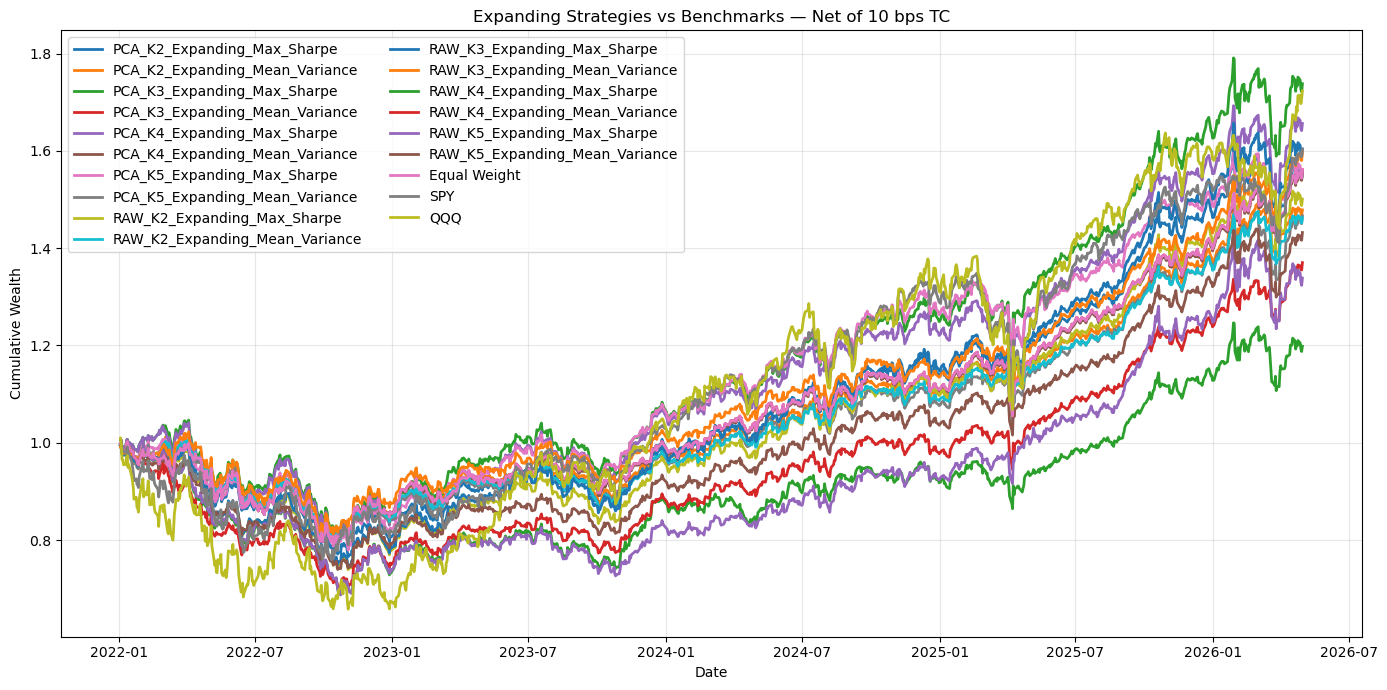

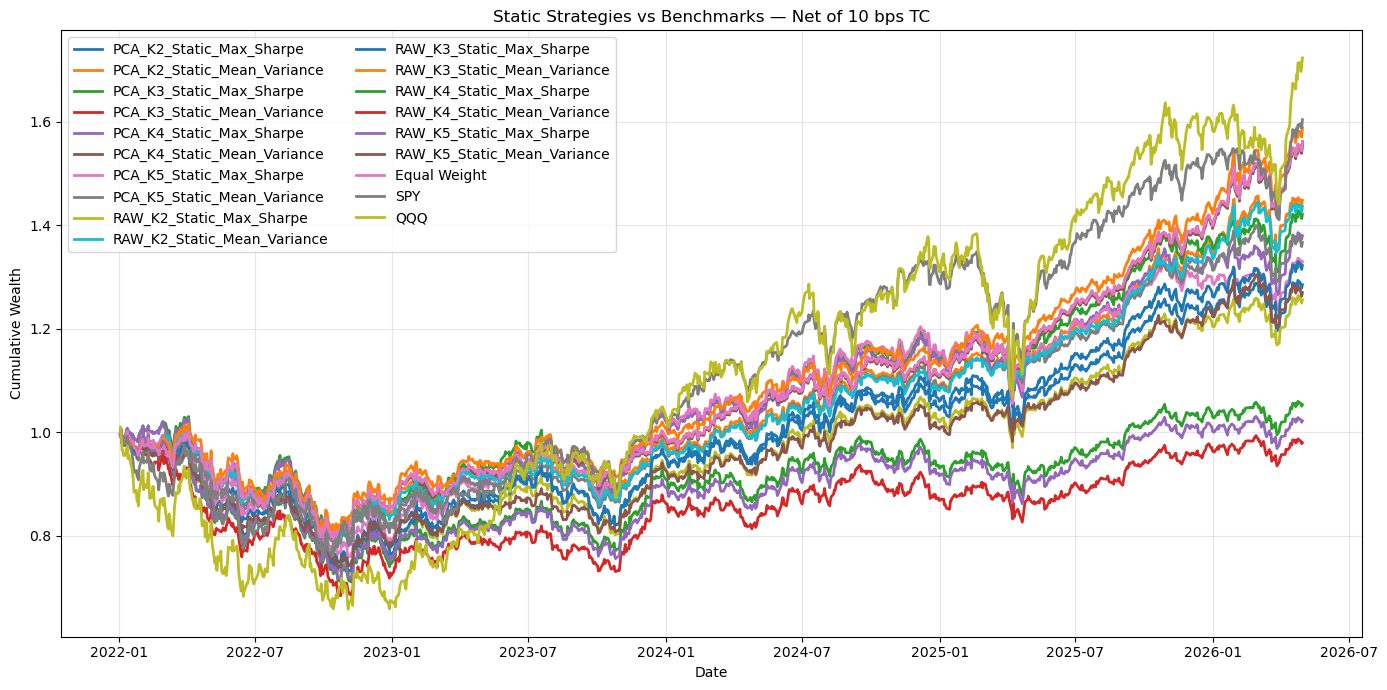

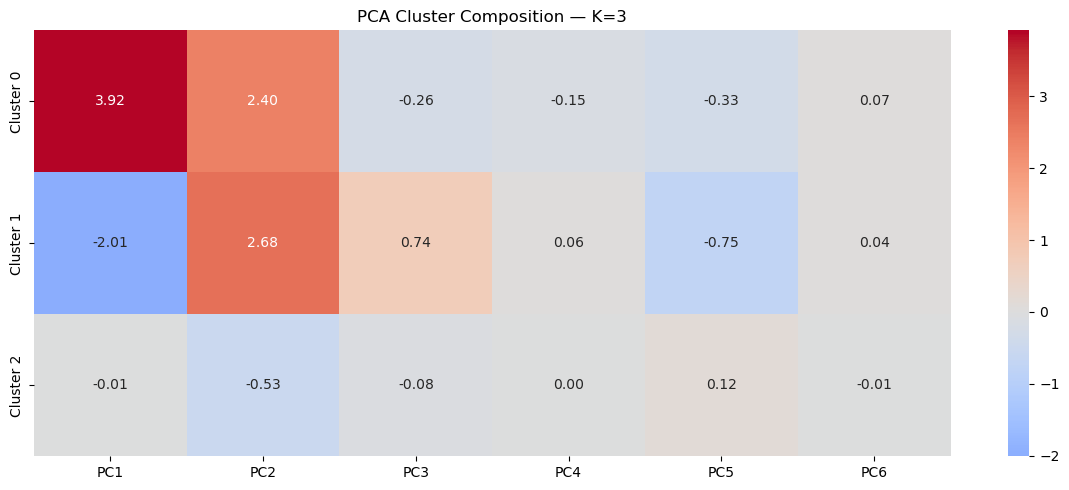

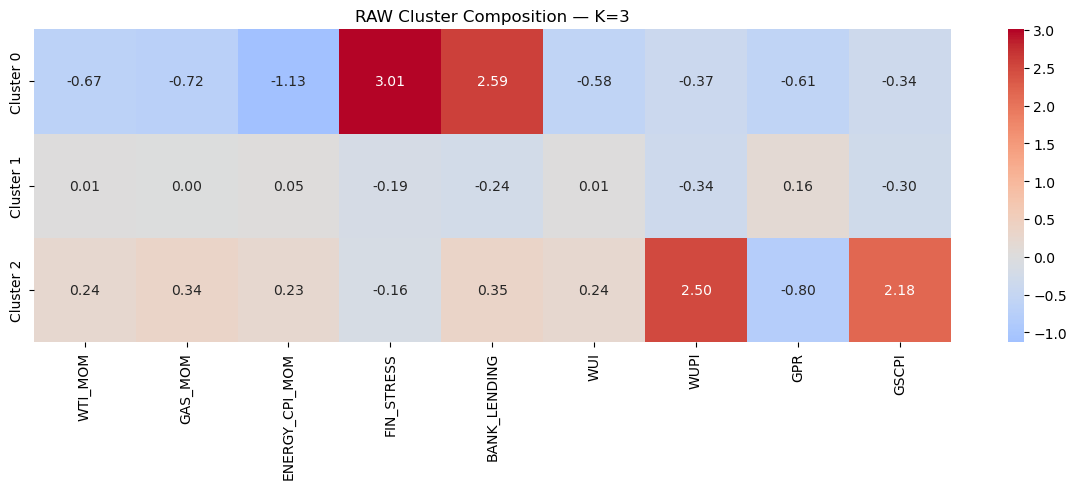

Best model       : PCA_K3_Expanding_Max_Sharpe
Static complement: PCA_K3_Static_Max_Sharpe


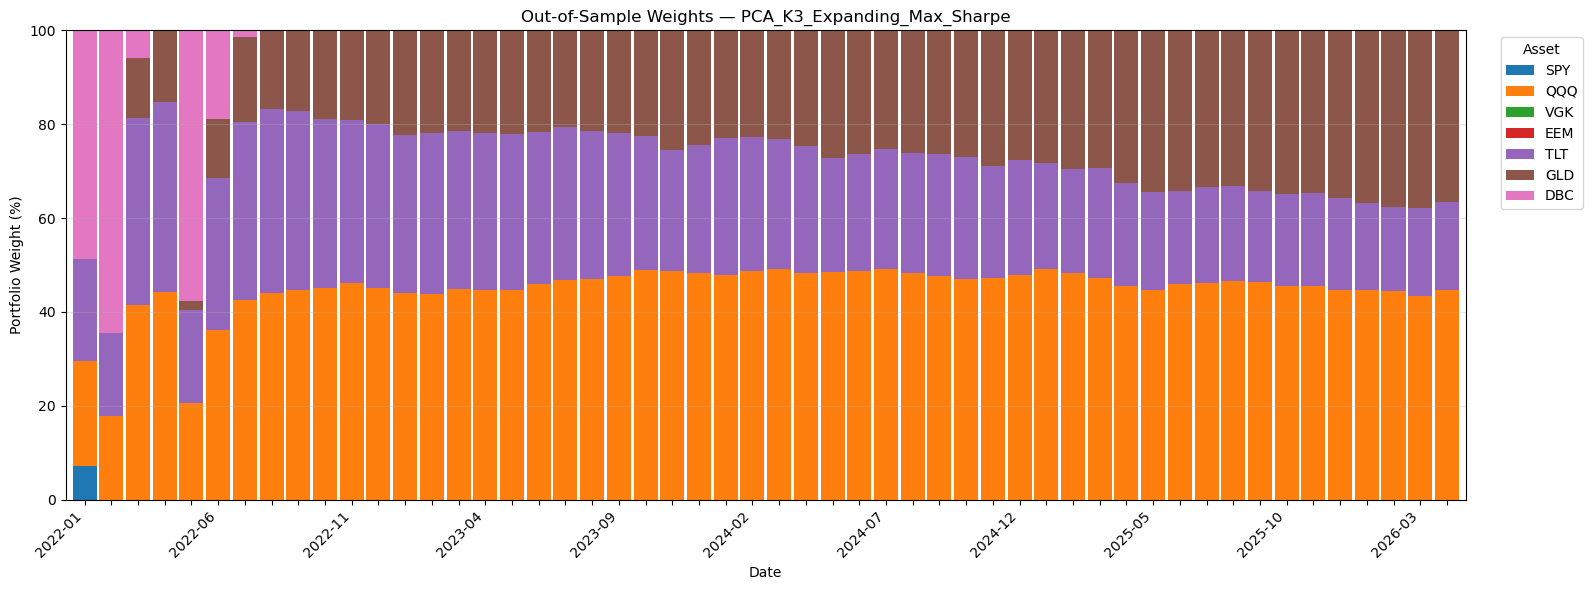

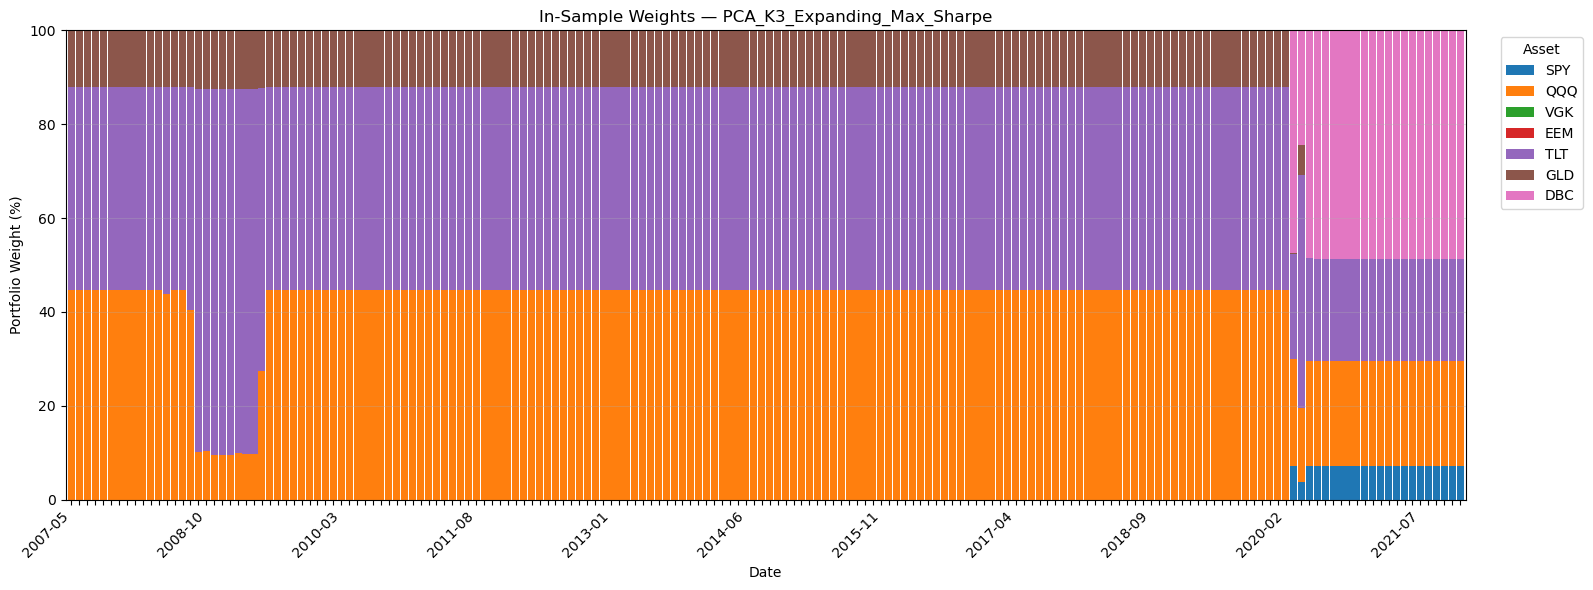

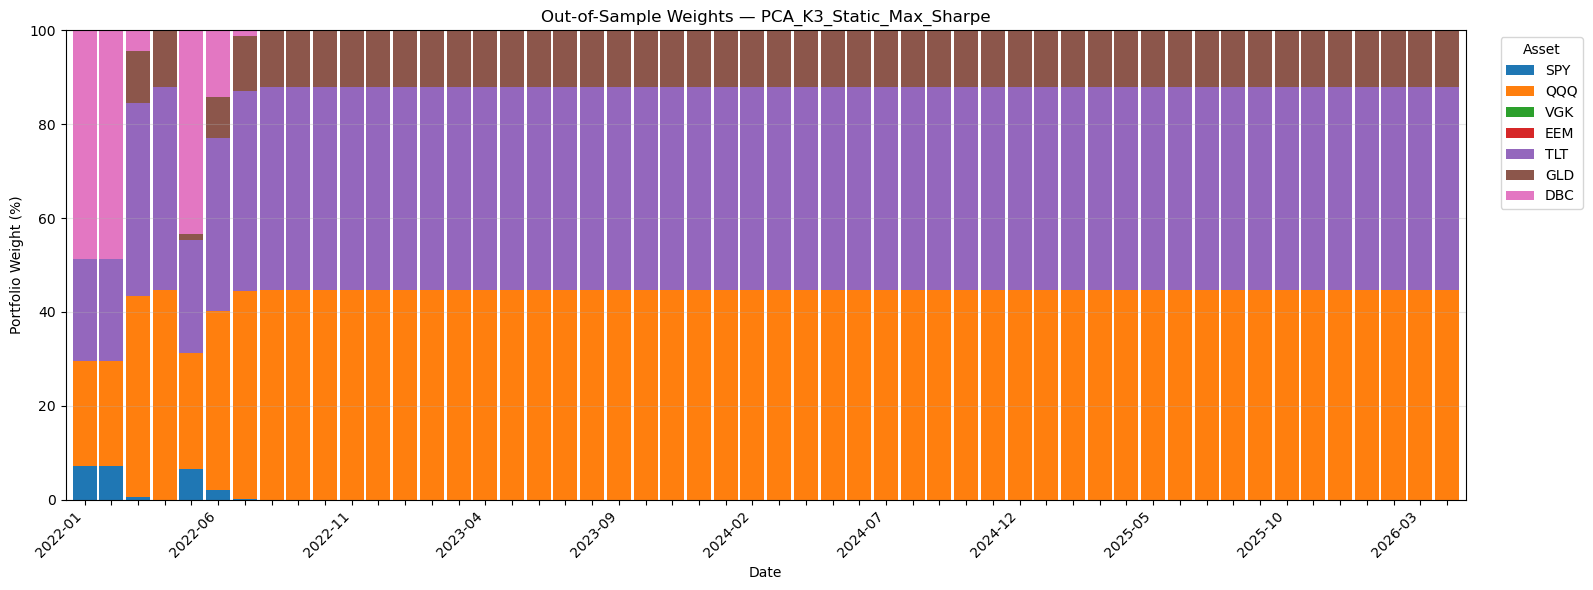

In [12]:

# ============================================
# UNIFIED OUT-OF-SAMPLE PERFORMANCE TABLE
# ============================================
 
perf_records = []
 
for key, net_ret in all_returns.items():
    parts      = key.split("_")
    feature    = parts[0]
    n_clusters = int(parts[1].replace("K", ""))
    strategy   = "_".join(parts[2:])
 
    rf        = returns_daily.loc[net_ret.index, "BIL"]
    benchmark = returns_daily.loc[net_ret.index, "QQQ"]
    metrics   = performance_metrics(net_ret, rf, benchmark_returns=benchmark)
 
    perf_records.append({
        "Features":  feature,
        "Clusters":  n_clusters,
        "Strategy":  strategy,
        **metrics.to_dict()
    })
 
for name, ret in [
    ("Equal Weight",               equal_weight_returns),
    ("SPY",                        spy_returns),
    ("QQQ",                        qqq_returns),
    ("BM_Max_Sharpe_NoClusters",   bm_sharpe_net),
    ("BM_MeanVariance_NoClusters", bm_mv_net),
]:
    rf        = returns_daily.loc[ret.index, "BIL"]
    benchmark = returns_daily.loc[ret.index, "QQQ"]
    metrics   = performance_metrics(ret, rf, benchmark_returns=benchmark)
    perf_records.append({"Features": "Benchmark", "Clusters": "-", "Strategy": name, **metrics.to_dict()})
 
performance_df = (
    pd.DataFrame(perf_records)
    .sort_values(by="Sharpe Ratio", ascending=False)
    .reset_index(drop=True)
)
 
print("\n" + "=" * 80)
print("OUT-OF-SAMPLE PERFORMANCE — NET OF 10 BPS TRANSACTION COSTS")
print("=" * 80)
print(performance_df.to_string(index=False))
 
 
# ============================================
# PLOT 1: EXPANDING STRATEGIES vs BENCHMARKS
# ============================================
 
expanding_keys = [k for k in all_returns if "Expanding" in k]
plot_series = {k: all_returns[k] for k in expanding_keys}
plot_series["Equal Weight"] = equal_weight_returns
plot_series["SPY"]          = spy_returns
plot_series["QQQ"]          = qqq_returns
 
cum_expanding = pd.concat(
    [(1 + ret).cumprod().rename(name) for name, ret in plot_series.items()], axis=1
).dropna()
 
plt.figure(figsize=(14, 7))
for col in cum_expanding.columns:
    plt.plot(cum_expanding.index, cum_expanding[col], linewidth=2, label=col)
plt.title("Expanding Strategies vs Benchmarks — Net of 10 bps TC")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
 
 
# ============================================
# PLOT 2: STATIC STRATEGIES vs BENCHMARKS
# ============================================
 
static_keys = [k for k in all_returns if "Static" in k]
plot_series_static = {k: all_returns[k] for k in static_keys}
plot_series_static["Equal Weight"] = equal_weight_returns
plot_series_static["SPY"]          = spy_returns
plot_series_static["QQQ"]                 = qqq_returns

 
cum_static = pd.concat(
    [(1 + ret).cumprod().rename(name) for name, ret in plot_series_static.items()], axis=1
).dropna()
 
plt.figure(figsize=(14, 7))
for col in cum_static.columns:
    plt.plot(cum_static.index, cum_static[col], linewidth=2, label=col)
plt.title("Static Strategies vs Benchmarks — Net of 10 bps TC")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
 
 
# ============================================
# PLOT 3: CLUSTER COMPOSITION HEATMAPS
# ============================================
 
def get_cluster_centroids(features_train, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(features_train)
    return pd.DataFrame(
        kmeans.cluster_centers_,
        columns=features_train.columns,
        index=[f"Cluster {i}" for i in range(n_clusters)]
    )
 
best_pca_k = int(performance_df[performance_df["Features"] == "PCA"].iloc[0]["Clusters"])
best_raw_k = int(performance_df[performance_df["Features"] == "RAW"].iloc[0]["Clusters"])
 
for feat_name, feat_train, best_k in [
    ("PCA", feature_sets["PCA"]["train"], best_pca_k),
    ("RAW", feature_sets["RAW"]["train"], best_raw_k),
]:
    centroids = get_cluster_centroids(feat_train, best_k)
    plt.figure(figsize=(12, 5))
    sns.heatmap(centroids, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title(f"{feat_name} Cluster Composition — K={best_k}")
    plt.tight_layout()
    plt.show()
 
 
# ============================================
# PLOT 4: WEIGHTS — BEST OVERALL MODEL
# ============================================
 
best_key      = performance_df[~performance_df["Features"].eq("Benchmark")].iloc[0]
best_feature  = best_key["Features"]
best_clusters = int(best_key["Clusters"])
best_strategy = best_key["Strategy"]
best_model_key = f"{best_feature}_K{best_clusters}_{best_strategy}"
 
optim_suffix    = "Max_Sharpe" if "Sharpe" in best_strategy else "Mean_Variance"
static_comp_key = f"{best_feature}_K{best_clusters}_Static_{optim_suffix}"
 
print(f"Best model       : {best_model_key}")
print(f"Static complement: {static_comp_key}")
 
# Re-run best model to get in-sample probabilities and regime weights
best_model = fit_regime_model(
    feature_sets[best_feature]["train"],
    feature_sets[best_feature]["test"],
    best_clusters
)
 
best_static_sharpe_w, best_static_mv_w = static_regime_weights(
    best_model["train_clusters"],
    feature_sets[best_feature]["train"]
)
best_regime_weights = best_static_sharpe_w if "Sharpe" in best_strategy else best_static_mv_w
 
# Build in-sample daily weights
train_probs = best_model["regime_probs_all"].loc[
    best_model["regime_probs_all"].index < split_date
].copy()
train_probs.index = train_probs.index.to_period("M")
train_probs_lagged = train_probs.shift(1)
 
returns_train_tmp = returns_daily.loc[returns_daily.index < split_date, risky_assets].copy()
returns_train_tmp["month"] = returns_train_tmp.index.to_period("M")
 
probs_daily_train = (
    returns_train_tmp[["month"]]
    .merge(train_probs_lagged, left_on="month", right_index=True, how="left")
)
probs_daily_train.index = returns_train_tmp.index
probs_daily_train = probs_daily_train.drop(columns="month").dropna()
 
common = best_regime_weights.index.intersection(probs_daily_train.columns)
probs_daily_train = probs_daily_train[common].div(probs_daily_train[common].sum(axis=1), axis=0)
weights_insample_best = probs_daily_train @ best_regime_weights.loc[common]
 
plot_stacked_weights(all_weights[best_model_key],  f"Out-of-Sample Weights — {best_model_key}")
plot_stacked_weights(weights_insample_best,         f"In-Sample Weights — {best_model_key}")
plot_stacked_weights(all_weights[static_comp_key], f"Out-of-Sample Weights — {static_comp_key}")



HORSE RACE — IN-SAMPLE vs OUT-OF-SAMPLE SHARPE RANKING
Expanding strategies (OOS) matched to their in-sample equivalent
Rank Δ = OOS Rank − IS Rank  →  positive = dropped in OOS, negative = improved
Features  Clusters     Optimizer  IS Sharpe  IS Rank  OOS Sharpe  OOS Rank  Rank Δ
     PCA         3    Max_Sharpe     1.3101        1      0.7122         1       0
     PCA         5    Max_Sharpe     1.2596        2      0.5512         7       5
     RAW         3    Max_Sharpe     1.2361        3      0.5800         5       2
     PCA         2    Max_Sharpe     1.2322        4      0.5430         8       4
     RAW         2    Max_Sharpe     1.2132        5      0.4806        11       6
     PCA         5 Mean_Variance     1.2083        6      0.4722        12       6
     RAW         4    Max_Sharpe     1.1095        7      0.0975        16       9
     PCA         4    Max_Sharpe     1.1086        8      0.6316         2      -6
     RAW         5    Max_Sharpe     1.0814        9 

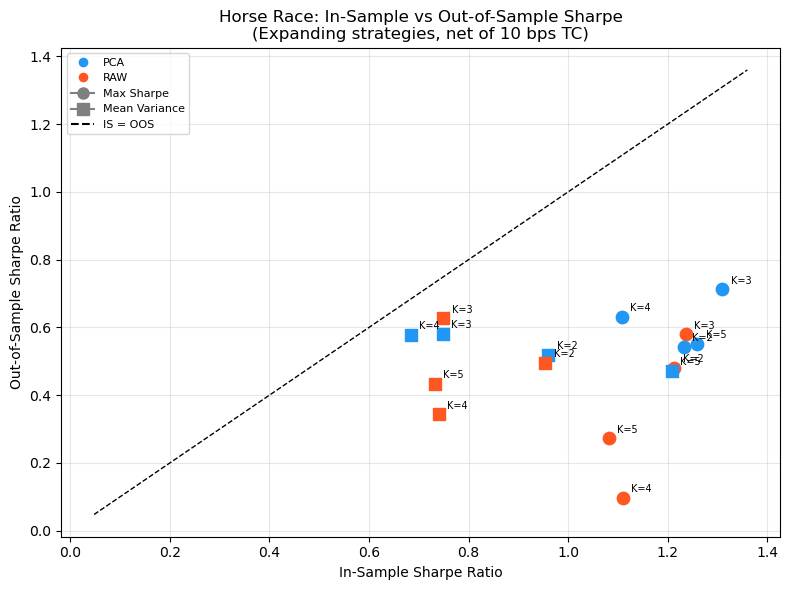

In [13]:

# ============================================
# HORSE RACE: IN-SAMPLE vs OUT-OF-SAMPLE
# SHARPE RANKING
# ============================================
#
# Per ogni combinazione (Feature, K, Optimizer)
# il confronto è possibile solo sull'ottimizzatore
# e sul feature set/K, NON sulla distinzione
# Static/Expanding: in-sample i due approcci
# producono pesi identici (nessun dato OOS
# disponibile per aggiornare la PCA/KMeans).
#
# In-sample Sharpe: calcolato sui rendimenti
# del training period (pre split_date), usando
# i pesi regime-conditioned costruiti sul training.
#
# Out-of-sample Sharpe: già in performance_df,
# filtrato sulle sole strategie Expanding
# (più rappresentative del framework regime-conditioned
# in quanto aggiornano mu/cov mensilmente).
# ============================================
 
# ── 1. IN-SAMPLE SHARPE per ogni (Feature, K, Optimizer) ──────────────────
 
is_records = []
 
for feature_name, feature_data in feature_sets.items():
    features_train = feature_data["train"]
 
    for n_clusters in N_CLUSTERS_LIST:
 
        model_is = fit_regime_model(
            features_train,
            feature_data["test"],   # test usato solo per fit_regime_model, non entra nei rendimenti IS
            n_clusters
        )
 
        sharpe_w_is, mv_w_is = static_regime_weights(
            model_is["train_clusters"], features_train
        )
 
        # Costruisci pesi giornalieri in-sample (stesso meccanismo del backtest)
        train_probs_is = model_is["regime_probs_all"].loc[
            model_is["regime_probs_all"].index < split_date
        ].copy()
        train_probs_is.index = train_probs_is.index.to_period("M")
        train_probs_is_lagged = train_probs_is.shift(1)
 
        ret_train = returns_daily.loc[
            returns_daily.index < split_date, risky_assets
        ].copy()
        ret_train["month"] = ret_train.index.to_period("M")
 
        probs_daily_is = (
            ret_train[["month"]]
            .merge(train_probs_is_lagged, left_on="month", right_index=True, how="left")
        )
        probs_daily_is.index = ret_train.index
        probs_daily_is = probs_daily_is.drop(columns="month").dropna()
        ret_train_clean = ret_train.loc[probs_daily_is.index, risky_assets]
 
        rf_is = returns_daily.loc[probs_daily_is.index, "BIL"]
 
        for optimizer_label, regime_w_df in [("Max_Sharpe", sharpe_w_is),
                                              ("Mean_Variance", mv_w_is)]:
            common = regime_w_df.index.intersection(probs_daily_is.columns)
            p = probs_daily_is[common].div(probs_daily_is[common].sum(axis=1), axis=0)
            w_is = p @ regime_w_df.loc[common]
 
            gross_is = (w_is * ret_train_clean).sum(axis=1)
            net_is   = apply_transaction_costs(gross_is, w_is)
 
            ann_ret = net_is.mean() * 252
            ann_vol = net_is.std() * np.sqrt(252)
            rf_ann  = rf_is.mean() * 252
            sharpe_is = (ann_ret - rf_ann) / ann_vol
 
            is_records.append({
                "Features":  feature_name,
                "Clusters":  n_clusters,
                "Optimizer": optimizer_label,
                "IS Sharpe": round(sharpe_is, 4),
            })
 
is_df = pd.DataFrame(is_records)
is_df["IS Rank"] = is_df["IS Sharpe"].rank(ascending=False).astype(int)
 
 
# ── 2. OUT-OF-SAMPLE SHARPE — strategie Expanding ─────────────────────────
# Usiamo Expanding come rappresentative: aggiornano mu/cov ogni mese.
# La distinzione Static/Expanding non esiste in-sample, quindi
# ancoriamo il confronto OOS alla sola variante Expanding.
 
oos_records = []
 
for key, net_ret in all_returns.items():
    if "Expanding" not in key:
        continue
 
    parts      = key.split("_")
    feature    = parts[0]
    n_clusters = int(parts[1].replace("K", ""))
    # Optimizer: Max_Sharpe o Mean_Variance
    optimizer  = "Max_Sharpe" if "Max_Sharpe" in key else "Mean_Variance"
 
    rf  = returns_daily.loc[net_ret.index, "BIL"]
    ann_ret = net_ret.mean() * 252
    ann_vol = net_ret.std() * np.sqrt(252)
    rf_ann  = rf.mean() * 252
    sharpe_oos = (ann_ret - rf_ann) / ann_vol
 
    oos_records.append({
        "Features":   feature,
        "Clusters":   n_clusters,
        "Optimizer":  optimizer,
        "OOS Sharpe": round(sharpe_oos, 4),
    })
 
oos_df = pd.DataFrame(oos_records)
oos_df["OOS Rank"] = oos_df["OOS Sharpe"].rank(ascending=False).astype(int)
 
 
# ── 3. MERGE E TABELLA FINALE ──────────────────────────────────────────────
 
horse_race = pd.merge(is_df, oos_df, on=["Features", "Clusters", "Optimizer"])
 
horse_race = horse_race.sort_values("IS Rank").reset_index(drop=True)
 
horse_race["Rank Δ"] = horse_race["OOS Rank"] - horse_race["IS Rank"]
 
horse_race = horse_race[[
    "Features", "Clusters", "Optimizer",
    "IS Sharpe", "IS Rank",
    "OOS Sharpe", "OOS Rank",
    "Rank Δ"
]]
 
print("\n" + "=" * 90)
print("HORSE RACE — IN-SAMPLE vs OUT-OF-SAMPLE SHARPE RANKING")
print("Expanding strategies (OOS) matched to their in-sample equivalent")
print("Rank Δ = OOS Rank − IS Rank  →  positive = dropped in OOS, negative = improved")
print("=" * 90)
print(horse_race.to_string(index=False))
 
# ── 4. SCATTER PLOT IS vs OOS SHARPE ──────────────────────────────────────
 
fig, ax = plt.subplots(figsize=(8, 6))
 
colors = {"PCA": "#2196F3", "RAW": "#FF5722"}
markers = {"Max_Sharpe": "o", "Mean_Variance": "s"}
 
for _, row in horse_race.iterrows():
    ax.scatter(
        row["IS Sharpe"], row["OOS Sharpe"],
        color=colors[row["Features"]],
        marker=markers[row["Optimizer"]],
        s=80, zorder=3
    )
    ax.annotate(
        f"K={row['Clusters']}",
        (row["IS Sharpe"], row["OOS Sharpe"]),
        textcoords="offset points", xytext=(6, 4), fontsize=7
    )
 
# 45° line: perfect IS=OOS ranking
lims = [
    min(horse_race["IS Sharpe"].min(), horse_race["OOS Sharpe"].min()) - 0.05,
    max(horse_race["IS Sharpe"].max(), horse_race["OOS Sharpe"].max()) + 0.05,
]
ax.plot(lims, lims, "k--", linewidth=1, label="IS = OOS")
 
# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2196F3", markersize=8, label="PCA"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#FF5722", markersize=8, label="RAW"),
    Line2D([0], [0], marker="o", color="gray", markersize=8, label="Max Sharpe"),
    Line2D([0], [0], marker="s", color="gray", markersize=8, label="Mean Variance"),
    Line2D([0], [0], linestyle="--", color="black", label="IS = OOS"),
]
ax.legend(handles=legend_elements, fontsize=8)
 
ax.set_xlabel("In-Sample Sharpe Ratio")
ax.set_ylabel("Out-of-Sample Sharpe Ratio")
ax.set_title("Horse Race: In-Sample vs Out-of-Sample Sharpe\n(Expanding strategies, net of 10 bps TC)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


DIAG 1 — REGIME SIMILARITY: PCA vs RAW (Adjusted Rand Index)
  K=2 | ARI Train=1.000 | ARI Test=1.000
  K=3 | ARI Train=0.948 | ARI Test=1.000
  K=4 | ARI Train=0.363 | ARI Test=0.515
  K=5 | ARI Train=0.384 | ARI Test=0.187

Interpretazione: ARI > 0.7 → regimi PCA e RAW quasi identici.
In quel caso la performance è guidata dall'ottimizzatore, non dal clustering.

DIAG 2 — WEIGHT CONCENTRATION (HHI) & TURNOVER
                         Model  Avg HHI  Avg Max W  Avg N Assets  Avg Turnover
   RAW_K4_Static_Mean_Variance   0.4964     0.6475        3.8400        0.0101
      RAW_K4_Static_Max_Sharpe   0.4722     0.6223        3.3600        0.0078
      RAW_K5_Static_Max_Sharpe   0.4712     0.6329        3.2800        0.0102
   RAW_K4_Expanding_Max_Sharpe   0.4621     0.5611        2.9800        0.0085
   RAW_K5_Expanding_Max_Sharpe   0.4419     0.5596        3.1300        0.0114
      PCA_K5_Static_Max_Sharpe   0.4246     0.4858        2.9100        0.0055
      PCA_K4_Static_Max_Sharpe  

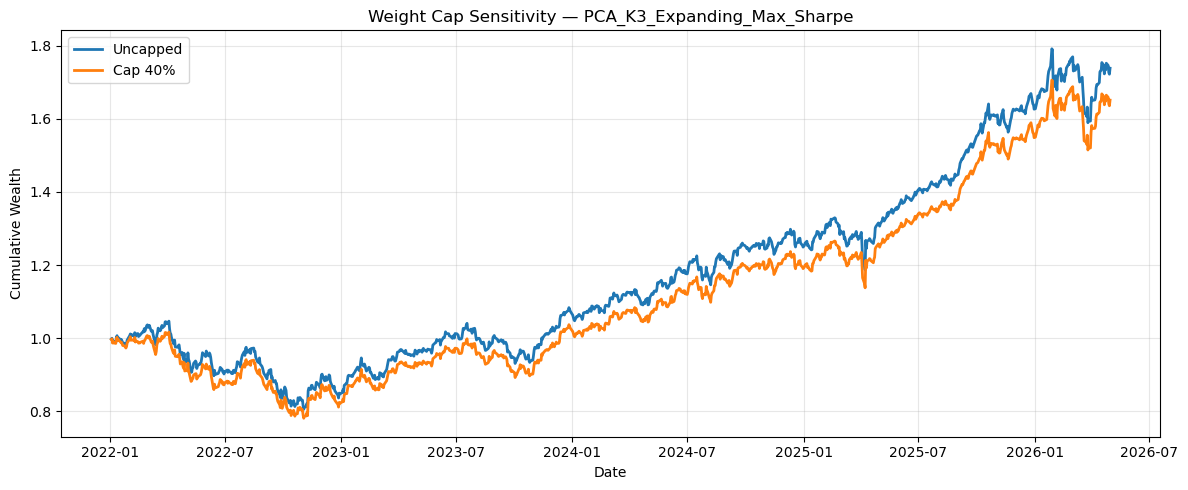


DIAG 3 — LOOK-AHEAD AUDIT

[3a] StandardScaler — fit solo su train:
     Train end  : 2021-12-31
     Test start : 2022-01-31
     ✓ scaler.fit_transform() chiamato solo su macro_train

[3b] PCA — fit solo su train:
     n_components : 9
     Fit range    : 2006-04-30 — 2021-12-31
     ✓ pca.fit() chiamato solo su macro_train_scaled
     ⚠ La PCA non viene rifatta mensilmente nell'expanding window.
       La struttura fattoriale è fissa al split_date. Limitazione nota,
       non introduce look-ahead ma riduce la purezza dell'expanding setup.

[3c] KMeans + LDA — fit solo su train:
     ✓ fit_regime_model() fitta KMeans e LDA su features_train
     ✓ Le probabilità OOS vengono shiftate di 1 mese prima dell'uso

[3d] Expanding window — barriera temporale:
     Mese campione : 2022-04
     ✓ Solo dati con index.period < 2022-04 vengono usati

[3e] Regime probabilities — verifica shift(1):
     ✓ Prima riga dopo shift(1) è NaN: True

------------------------------------------------------

In [14]:

# ============================================
# DIAG 1: REGIME SIMILARITY — PCA vs RAW (ARI)
# ARI = 1 → identical clusters, ARI ≈ 0 → random.
# High ARI → performance is driven by the optimizer,
# not by the clustering representation.
# ============================================
 
print("\n" + "=" * 60)
print("DIAG 1 — REGIME SIMILARITY: PCA vs RAW (Adjusted Rand Index)")
print("=" * 60)
 
ari_records = []
for n_clusters in N_CLUSTERS_LIST:
    pca_model_diag = fit_regime_model(feature_sets["PCA"]["train"], feature_sets["PCA"]["test"], n_clusters)
    raw_model_diag = fit_regime_model(feature_sets["RAW"]["train"], feature_sets["RAW"]["test"], n_clusters)
    ari_train = adjusted_rand_score(pca_model_diag["train_clusters"], raw_model_diag["train_clusters"])
    ari_test  = adjusted_rand_score(pca_model_diag["test_clusters"],  raw_model_diag["test_clusters"])
    ari_records.append({"K": n_clusters, "ARI Train": ari_train, "ARI Test": ari_test})
    print(f"  K={n_clusters} | ARI Train={ari_train:.3f} | ARI Test={ari_test:.3f}")
 
print("\nInterpretazione: ARI > 0.7 → regimi PCA e RAW quasi identici.")
print("In quel caso la performance è guidata dall'ottimizzatore, non dal clustering.")
 
 
# ============================================
# DIAG 2: WEIGHT CONCENTRATION (HHI) & TURNOVER
# HHI = sum(w_i²): 1 = fully concentrated, 1/N = EW.
# ============================================
 
print("\n" + "=" * 60)
print("DIAG 2 — WEIGHT CONCENTRATION (HHI) & TURNOVER")
print("=" * 60)
 
conc_records = []
for key, wts in all_weights.items():
    hhi       = (wts ** 2).sum(axis=1).mean()
    turnover  = wts.diff().abs().sum(axis=1).mean()
    max_w_avg = wts.max(axis=1).mean()
    n_active  = (wts > 0.01).sum(axis=1).mean()
    conc_records.append({
        "Model":        key,
        "Avg HHI":      round(hhi, 4),
        "Avg Max W":    round(max_w_avg, 4),
        "Avg N Assets": round(n_active, 2),
        "Avg Turnover": round(turnover, 4),
    })
 
conc_df = (
    pd.DataFrame(conc_records)
    .sort_values("Avg HHI", ascending=False)
    .reset_index(drop=True)
)
print(conc_df.to_string(index=False))
 
# --- Sensitivity: 40% weight cap on best model ---
print(f"\n--- Sensitivity weight cap 40% — {best_model_key} ---")
 
optim_suffix_cap = "Max_Sharpe" if "Sharpe" in best_strategy else "Mean_Variance"
 
 
def backtest_expanding_capped(features_train, features_test, train_clusters,
                               test_clusters, lda, regime_probs_all, max_w=0.40):
    monthly_clusters_all = pd.concat([
        pd.DataFrame({"cluster": train_clusters}, index=features_train.index),
        pd.DataFrame({"cluster": test_clusters},  index=features_test.index)
    ]).sort_index()
    monthly_clusters_all.index = monthly_clusters_all.index.to_period("M")
 
    probs_all = regime_probs_all.copy()
    probs_all.index = probs_all.index.to_period("M")
    probs_all_lagged = probs_all.shift(1)
 
    test_months  = features_test.index.to_period("M").unique().sort_values()
    weights_list = []
 
    for current_month in test_months:
        available_clusters = monthly_clusters_all.loc[monthly_clusters_all.index < current_month]
        hist_returns = returns_daily.loc[
            returns_daily.index.to_period("M") < current_month, risky_assets + ["BIL"]
        ].copy()
        hist_returns["month"] = hist_returns.index.to_period("M")
        hist_with_regime = hist_returns.merge(
            available_clusters, left_on="month", right_index=True, how="left"
        ).dropna()
 
        regime_w = {}
        for regime in sorted(hist_with_regime["cluster"].unique()):
            subset = hist_with_regime[hist_with_regime["cluster"] == regime]
            r = subset[risky_assets]
            if len(r) < 20:
                continue
            mu  = r.mean()
            cov = r.cov()
            rf  = subset["BIL"].mean()
            if "Sharpe" in optim_suffix_cap:
                regime_w[regime] = max_sharpe_ratio(mu, cov, rf, max_weight=max_w)
            else:
                regime_w[regime] = mean_variance_optimization(mu, cov, max_weight=max_w)
 
        w_df        = pd.DataFrame(regime_w, index=risky_assets).T.sort_index()
        probs_month = probs_all_lagged.loc[current_month]
        days_month  = returns_daily.loc[
            returns_daily.index.to_period("M") == current_month
        ].index
 
        common  = w_df.index.intersection(probs_month.index)
        probs   = probs_month.loc[common] / probs_month.loc[common].sum()
        w_month = probs @ w_df.loc[common]
        weights_list.append(pd.DataFrame(
            np.tile(w_month.values, (len(days_month), 1)),
            index=days_month, columns=risky_assets
        ))
 
    w_capped   = pd.concat(weights_list).sort_index()
    ret_assets = returns_daily.loc[w_capped.index, risky_assets]
    return (w_capped * ret_assets).sum(axis=1), w_capped
 
 
best_model_cap = fit_regime_model(
    feature_sets[best_feature]["train"],
    feature_sets[best_feature]["test"],
    best_clusters
)
 
capped_gross, capped_wts = backtest_expanding_capped(
    feature_sets[best_feature]["train"],
    feature_sets[best_feature]["test"],
    best_model_cap["train_clusters"],
    best_model_cap["test_clusters"],
    best_model_cap["lda"],
    best_model_cap["regime_probs_all"],
    max_w=0.40
)
capped_net   = apply_transaction_costs(capped_gross, capped_wts)
uncapped_net = all_returns[best_model_key]
 
rf_test = returns_daily.loc[capped_net.index, "BIL"]
 
cap_comparison = pd.DataFrame({
    "Uncapped": performance_metrics(uncapped_net.loc[capped_net.index], rf_test),
    "Cap 40%":  performance_metrics(capped_net, rf_test),
}).T
print(cap_comparison.round(4).to_string())
 
cum_cap = pd.DataFrame({
    "Uncapped": (1 + uncapped_net.loc[capped_net.index]).cumprod(),
    "Cap 40%":  (1 + capped_net).cumprod(),
})
plt.figure(figsize=(12, 5))
for col in cum_cap.columns:
    plt.plot(cum_cap.index, cum_cap[col], linewidth=2, label=col)
plt.title(f"Weight Cap Sensitivity — {best_model_key}")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
 
# ============================================
# DIAG 3: LOOK-AHEAD AUDIT
# ============================================
 
print("\n" + "=" * 60)
print("DIAG 3 — LOOK-AHEAD AUDIT")
print("=" * 60)
 
print("\n[3a] StandardScaler — fit solo su train:")
print(f"     Train end  : {macro_train.index.max().date()}")
print(f"     Test start : {macro_test.index.min().date()}")
print(f"     ✓ scaler.fit_transform() chiamato solo su macro_train")
 
print("\n[3b] PCA — fit solo su train:")
print(f"     n_components : {pca.n_components_}")
print(f"     Fit range    : {macro_train_scaled.index.min().date()} — {macro_train_scaled.index.max().date()}")
print(f"     ✓ pca.fit() chiamato solo su macro_train_scaled")
print(f"     ⚠ La PCA non viene rifatta mensilmente nell'expanding window.")
print(f"       La struttura fattoriale è fissa al split_date. Limitazione nota,")
print(f"       non introduce look-ahead ma riduce la purezza dell'expanding setup.")
 
print("\n[3c] KMeans + LDA — fit solo su train:")
print(f"     ✓ fit_regime_model() fitta KMeans e LDA su features_train")
print(f"     ✓ Le probabilità OOS vengono shiftate di 1 mese prima dell'uso")
 
sample_month = feature_sets["PCA"]["test"].index.to_period("M").unique()[3]
print(f"\n[3d] Expanding window — barriera temporale:")
print(f"     Mese campione : {sample_month}")
print(f"     ✓ Solo dati con index.period < {sample_month} vengono usati")
 
_probs_check  = best_model["regime_probs_all"].copy()
_probs_check.index = _probs_check.index.to_period("M")
_lagged_check = _probs_check.shift(1)
print(f"\n[3e] Regime probabilities — verifica shift(1):")
print(f"     ✓ Prima riga dopo shift(1) è NaN: {_lagged_check.iloc[0].isna().all()}")
 
print("\n" + "-" * 60)
print("SINTESI:")
print("  ✓ Scaler fittato solo su training")
print("  ✓ PCA fittata solo su training")
print("  ✓ KMeans e LDA fittati solo su training")
print("  ✓ Expanding window usa solo dati storicamente disponibili")
print("  ✓ Probabilità di regime lagged di 1 mese")
print("  ⚠ PCA fissa al split_date (limitazione, non look-ahead)")
print("=" * 60)
 


In [15]:

# ============================================
# GARCH(1,1) MONTHLY FORECAST — BEST MODEL & QQQ
# For each month, a GARCH(1,1) is fitted on all
# available history up to t-1 (expanding window)
# for both the portfolio and QQQ separately.
# The table reports forecast and realized volatility
# for both series, plus their monthly returns.
# ============================================
 
best_returns   = all_returns[best_model_key].copy().dropna()
market_returns = qqq_returns.copy()
market_returns = market_returns.loc[best_returns.index].dropna()
 
common_index   = best_returns.index.intersection(market_returns.index)
best_returns   = best_returns.loc[common_index]
market_returns = market_returns.loc[common_index]
 
test_months   = best_returns.index.to_period("M").unique().sort_values()
garch_records = []
 
for current_month in test_months:
 
    # ── Portfolio slices ───────────────────────────────────────────────────
    port_hist  = best_returns.loc[best_returns.index.to_period("M") < current_month].dropna()
    port_month = best_returns.loc[best_returns.index.to_period("M") == current_month].dropna()
 
    # ── QQQ slices ────────────────────────────────────────────────────────
    qqq_hist   = market_returns.loc[market_returns.index.to_period("M") < current_month].dropna()
    qqq_month  = market_returns.loc[market_returns.index.to_period("M") == current_month].dropna()
 
    if len(port_hist) < 250 or len(port_month) == 0:
        continue
 
    horizon = len(port_month)
 
    # ── GARCH(1,1) — Portfolio ────────────────────────────────────────────
    res_port      = arch_model(port_hist * 100, mean="Constant", vol="GARCH", p=1, q=1, dist="normal").fit(disp="off")
    fcast_port    = res_port.forecast(horizon=horizon, reindex=False)
    port_fcast_vol = np.sqrt(np.sum(fcast_port.variance.values[-1])) / 100
    port_real_vol  = port_month.std() * np.sqrt(horizon)
 
    # ── GARCH(1,1) — QQQ ─────────────────────────────────────────────────
    res_qqq       = arch_model(qqq_hist * 100, mean="Constant", vol="GARCH", p=1, q=1, dist="normal").fit(disp="off")
    fcast_qqq     = res_qqq.forecast(horizon=horizon, reindex=False)
    qqq_fcast_vol  = np.sqrt(np.sum(fcast_qqq.variance.values[-1])) / 100
    qqq_real_vol   = qqq_month.std() * np.sqrt(horizon)
 
    garch_records.append({
        "Month":                       current_month.to_timestamp("M"),
        "Port Forecast Volatility":    port_fcast_vol,
        "Port Realized Volatility":    port_real_vol,
        "QQQ Forecast Volatility":     qqq_fcast_vol,
        "QQQ Realized Volatility":     qqq_real_vol,
        "Strategy Monthly Return":     (1 + port_month).prod() - 1,
        "QQQ Monthly Return":          (1 + qqq_month).prod() - 1,
    })
 
garch_df = pd.DataFrame(garch_records).set_index("Month")
print(garch_df.round(4))
 

            Port Forecast Volatility  Port Realized Volatility  QQQ Forecast Volatility  QQQ Realized Volatility  Strategy Monthly Return  QQQ Monthly Return
Month                                                                                                                                                        
2023-01-31                    0.0558                    0.0336                   0.0913                   0.0621                   0.0862              0.1064
2023-02-28                    0.0514                    0.0431                   0.0853                   0.0707                  -0.0297             -0.0036
2023-03-31                    0.0552                    0.0358                   0.0911                   0.0607                   0.0770              0.0949
2023-04-30                    0.0431                    0.0216                   0.0727                   0.0449                   0.0059              0.0051
2023-05-31                    0.0369                

In [16]:


# ============================================================

# 3) YEARLY ROLLING K-MEANS EXPERIMENT

# ============================================================

# Idea:

# - ogni anno t del test set:

#   1. rifitto scaler, PCA, KMeans e LDA usando dati fino a t-1

#   2. scelgo la migliore strategia dell'anno precedente

#   3. la applico nell'anno corrente

#

# Nota:

# Questo è un esperimento separato rispetto al portfolio analysis principale.

# Mantiene nomi compatibili: all_returns_yearly, all_weights_yearly.

# ============================================================

def build_features_until_date(macro_data, cutoff_date, use_pca=True, n_components=6):

    """

    Fit scaler and optionally PCA using only data before cutoff_date.

    """

    macro_hist = macro_data.loc[macro_data.index < cutoff_date].copy()

    scaler_year = StandardScaler()

    macro_hist_scaled = pd.DataFrame(

        scaler_year.fit_transform(macro_hist),

        columns=macro_hist.columns,

        index=macro_hist.index

    )

    if use_pca:

        pca_year = PCA()

        pca_year.fit(macro_hist_scaled)

        pca_hist = pd.DataFrame(

            pca_year.transform(macro_hist_scaled),

            columns=[f"PC{i+1}" for i in range(macro_hist_scaled.shape[1])],

            index=macro_hist_scaled.index

        )

        features_hist = pca_hist.iloc[:, :n_components].copy()

        return features_hist, scaler_year, pca_year

    else:

        return macro_hist_scaled, scaler_year, None

def transform_features_current_period(

    macro_data,

    start_date,

    end_date,

    scaler_year,

    pca_year=None,

    n_components=6

):

    """

    Transform current period using scaler/PCA fitted only on past data.

    """

    macro_current = macro_data.loc[

        (macro_data.index >= start_date) &

        (macro_data.index < end_date)

    ].copy()

    macro_current_scaled = pd.DataFrame(

        scaler_year.transform(macro_current),

        columns=macro_current.columns,

        index=macro_current.index

    )

    if pca_year is not None:

        pca_current = pd.DataFrame(

            pca_year.transform(macro_current_scaled),

            columns=[f"PC{i+1}" for i in range(macro_current_scaled.shape[1])],

            index=macro_current_scaled.index

        )

        return pca_current.iloc[:, :n_components].copy()

    else:

        return macro_current_scaled.copy()

def yearly_model_selection(previous_year_returns_dict):

    """

    Select best strategy from previous year based on Sharpe Ratio.

    """

    rows = []

    for key, ret in previous_year_returns_dict.items():

        if len(ret.dropna()) < 20:

            continue

        rf = returns_daily.loc[ret.index, "BIL"]

        metrics = performance_metrics(ret, rf)

        rows.append({

            "Key": key,

            "Sharpe Ratio": metrics["Sharpe Ratio"]

        })

    selection_df = pd.DataFrame(rows)

    if selection_df.empty:

        return None

    return (

        selection_df

        .sort_values("Sharpe Ratio", ascending=False)

        .iloc[0]["Key"]

    )

def run_yearly_rolling_kmeans_experiment(

    macro_data,

    start_test_year=split_date,

    end_test_year=end,

    n_clusters_list=[2, 3, 4, 5],

    feature_names=["PCA", "RAW"],

    tc_bps=10

):

    # --------------------------------------------------------
    # Converti sempre gli anni in interi
    # --------------------------------------------------------

    if not isinstance(start_test_year, int):
        start_test_year = pd.Timestamp(start_test_year).year

    if not isinstance(end_test_year, int):
        end_test_year = pd.Timestamp(end_test_year).year


    all_returns_yearly = {}
    all_weights_yearly = {}

    yearly_selected_models = []

    previous_year_strategy_returns = {}

    # Per la strategia adattiva finale:
    # salviamo rendimenti LORDI + pesi,
    # poi applichiamo TC una sola volta alla fine.
    final_gross_returns_list = []
    final_weights_list = []


    # --------------------------------------------------------
    # Warm-up year
    #
    # Per scegliere il modello da usare nel 2022
    # dobbiamo osservare le performance del 2021,
    # NON quelle 2022-2026.
    # --------------------------------------------------------

    warmup_year = start_test_year - 1


    for year in range(
        warmup_year,
        end_test_year + 1
    ):

        print(
            f"\nRunning yearly rolling KMeans for year {year}"
        )

        train_cutoff = pd.Timestamp(
            f"{year}-01-01"
        )

        year_start = pd.Timestamp(
            f"{year}-01-01"
        )

        year_end = pd.Timestamp(
            f"{year + 1}-01-01"
        )


        yearly_returns_candidates = {}
        yearly_gross_candidates = {}
        yearly_weights_candidates = {}


        # ====================================================
        # GENERATE ALL CANDIDATES FOR THIS YEAR
        # ====================================================

        for feature_name in feature_names:

            use_pca = feature_name == "PCA"


            # ------------------------------------------------
            # Fit features ONLY using data < Jan 1 current year
            # ------------------------------------------------

            features_train_year, scaler_year, pca_year = (
                build_features_until_date(

                    macro_data=macro_data,

                    cutoff_date=train_cutoff,

                    use_pca=use_pca,

                    n_components=6
                )
            )


            # ------------------------------------------------
            # Transform current year with past-fitted scaler/PCA
            # ------------------------------------------------

            features_test_year = (
                transform_features_current_period(

                    macro_data=macro_data,

                    start_date=year_start,

                    end_date=year_end,

                    scaler_year=scaler_year,

                    pca_year=pca_year,

                    n_components=6
                )
            )


            if features_test_year.empty:
                continue


            # =================================================
            # K LOOP
            # =================================================

            for n_clusters in n_clusters_list:

                model_year = fit_regime_model(

                    features_train=features_train_year,

                    features_test=features_test_year,

                    n_clusters=n_clusters
                )


                regime_probs_all_year = (
                    model_year["regime_probs_all"]
                )

                train_clusters_year = (
                    model_year["train_clusters"]
                )

                test_clusters_year = (
                    model_year["test_clusters"]
                )


                # ------------------------------------------------
                # Regime-conditioned weights
                #
                # La nuova static_regime_weights usa automaticamente
                # il vero cutoff del features_train_year.
                # ------------------------------------------------

                static_sharpe_w, static_mv_w = (
                    static_regime_weights(

                        train_clusters=train_clusters_year,

                        features_train=features_train_year
                    )
                )


                # ------------------------------------------------
                # STATIC
                # ------------------------------------------------

                (
                    static_sharpe_ret,
                    static_sharpe_wts
                ) = backtest_static(

                    regime_probs_all=
                        regime_probs_all_year,

                    regime_weights_df=
                        static_sharpe_w,

                    start_date=year_start,

                    end_date=year_end
                )


                (
                    static_mv_ret,
                    static_mv_wts
                ) = backtest_static(

                    regime_probs_all=
                        regime_probs_all_year,

                    regime_weights_df=
                        static_mv_w,

                    start_date=year_start,

                    end_date=year_end
                )


                # ------------------------------------------------
                # EXPANDING
                # ------------------------------------------------

                (
                    exp_sharpe_ret,
                    exp_sharpe_wts,

                    exp_mv_ret,
                    exp_mv_wts

                ) = backtest_expanding(

                    features_train=
                        features_train_year,

                    features_test=
                        features_test_year,

                    train_clusters=
                        train_clusters_year,

                    test_clusters=
                        test_clusters_year,

                    lda=model_year["lda"],

                    regime_probs_all=
                        regime_probs_all_year
                )


                strategies_year = {

                    "Static_Max_Sharpe":
                        (
                            static_sharpe_ret,
                            static_sharpe_wts
                        ),

                    "Static_Mean_Variance":
                        (
                            static_mv_ret,
                            static_mv_wts
                        ),

                    "Expanding_Max_Sharpe":
                        (
                            exp_sharpe_ret,
                            exp_sharpe_wts
                        ),

                    "Expanding_Mean_Variance":
                        (
                            exp_mv_ret,
                            exp_mv_wts
                        )
                }


                # =================================================
                # STORE CANDIDATES
                # =================================================

                for strategy_name, (
                    gross_ret,
                    weights
                ) in strategies_year.items():


                    gross_ret = gross_ret.loc[
                        (gross_ret.index >= year_start)
                        &
                        (gross_ret.index < year_end)
                    ]


                    if gross_ret.empty:
                        continue


                    weights = weights.loc[
                        gross_ret.index
                    ]


                    net_ret = apply_transaction_costs(

                        portfolio_returns=gross_ret,

                        weights=weights,

                        tc_bps=tc_bps
                    )


                    key = (
                        f"{feature_name}_"
                        f"K{n_clusters}_"
                        f"{strategy_name}"
                    )


                    yearly_gross_candidates[key] = (
                        gross_ret
                    )

                    yearly_returns_candidates[key] = (
                        net_ret
                    )

                    yearly_weights_candidates[key] = (
                        weights
                    )


        # ====================================================
        # WARM-UP YEAR
        # ====================================================
        #
        # Il 2021 serve SOLTANTO per scegliere il modello
        # da utilizzare nel 2022.
        #
        # Non entra nei rendimenti finali OOS.
        # ====================================================

        if year == warmup_year:

            previous_year_strategy_returns = (
                yearly_returns_candidates.copy()
            )

            print(
                f"Warm-up year {year}: "
                "used only for model selection."
            )

            continue


        # ====================================================
        # SELECT MODEL USING PREVIOUS YEAR ONLY
        # ====================================================

        selected_key = yearly_model_selection(
            previous_year_strategy_returns
        )


        if selected_key is None:

            raise ValueError(
                f"No valid model available from "
                f"{year - 1} to select strategy for {year}."
            )


        if selected_key not in yearly_returns_candidates:

            raise ValueError(
                f"Model selected from {year - 1} "
                f"({selected_key}) is not available in {year}."
            )


        print(
            f"Selected model for {year}: "
            f"{selected_key} "
            f"(based only on {year - 1})"
        )


        # ====================================================
        # ACTUAL ADAPTIVE STRATEGY
        # ====================================================

        selected_gross = (
            yearly_gross_candidates[selected_key]
        )

        selected_weights = (
            yearly_weights_candidates[selected_key]
        )


        yearly_selected_models.append({

            "Year": year,

            "Selection Based On": year - 1,

            "Selected Model": selected_key

        })


        final_gross_returns_list.append(
            selected_gross
        )

        final_weights_list.append(
            selected_weights
        )


        # ====================================================
        # STORE ALL CURRENT-YEAR CANDIDATES
        # ====================================================

        for key, ret in (
            yearly_returns_candidates.items()
        ):

            all_returns_yearly[
                f"{year}_{key}"
            ] = ret


        for key, w in (
            yearly_weights_candidates.items()
        ):

            all_weights_yearly[
                f"{year}_{key}"
            ] = w


        # ====================================================
        # THIS YEAR BECOMES NEXT YEAR'S SELECTION SAMPLE
        # ====================================================

        previous_year_strategy_returns = (
            yearly_returns_candidates.copy()
        )


    # ========================================================
    # CONCATENATE ACTUAL ADAPTIVE STRATEGY
    # ========================================================

    rolling_kmeans_gross_returns = (
        pd.concat(final_gross_returns_list)
        .sort_index()
    )

    rolling_kmeans_weights = (
        pd.concat(final_weights_list)
        .sort_index()
    )


    # --------------------------------------------------------
    # IMPORTANT:
    # transaction costs applied ONCE across whole test period.
    #
    # This correctly captures turnover when the selected
    # model changes between Dec 31 and Jan 1.
    # --------------------------------------------------------

    rolling_kmeans_returns = (
        apply_transaction_costs(

            portfolio_returns=
                rolling_kmeans_gross_returns,

            weights=
                rolling_kmeans_weights,

            tc_bps=
                tc_bps
        )
    )


    yearly_selection_df = pd.DataFrame(
        yearly_selected_models
    )


    return {

        "rolling_kmeans_returns":
            rolling_kmeans_returns,

        "rolling_kmeans_weights":
            rolling_kmeans_weights,

        "yearly_selection_df":
            yearly_selection_df,

        "all_returns_yearly":
            all_returns_yearly,

        "all_weights_yearly":
            all_weights_yearly
    }

In [17]:


# ============================================================

# 4) RUN YEARLY ROLLING K-MEANS

# ============================================================

rolling_kmeans_results = run_yearly_rolling_kmeans_experiment(
    macro_data=macro,
    start_test_year=pd.Timestamp(split_date).year,
    end_test_year=pd.Timestamp(end).year,
    n_clusters_list=N_CLUSTERS_LIST,
    feature_names=["PCA", "RAW"],
    tc_bps=TC_BPS
)

rolling_kmeans_returns = rolling_kmeans_results["rolling_kmeans_returns"]

rolling_kmeans_weights = rolling_kmeans_results["rolling_kmeans_weights"]

yearly_selection_df = rolling_kmeans_results["yearly_selection_df"]

all_returns_yearly = rolling_kmeans_results["all_returns_yearly"]

all_weights_yearly = rolling_kmeans_results["all_weights_yearly"]

print("\nYEARLY SELECTED MODELS")

print(yearly_selection_df)


Running yearly rolling KMeans for year 2021
Warm-up year 2021: used only for model selection.

Running yearly rolling KMeans for year 2022
Selected model for 2022: PCA_K2_Static_Mean_Variance (based only on 2021)

Running yearly rolling KMeans for year 2023
Selected model for 2023: RAW_K3_Expanding_Mean_Variance (based only on 2022)

Running yearly rolling KMeans for year 2024
Selected model for 2024: PCA_K3_Expanding_Max_Sharpe (based only on 2023)

Running yearly rolling KMeans for year 2025
Selected model for 2025: PCA_K5_Static_Max_Sharpe (based only on 2024)

Running yearly rolling KMeans for year 2026
Selected model for 2026: RAW_K2_Expanding_Mean_Variance (based only on 2025)

YEARLY SELECTED MODELS
   Year  Selection Based On                  Selected Model
0  2022                2021     PCA_K2_Static_Mean_Variance
1  2023                2022  RAW_K3_Expanding_Mean_Variance
2  2024                2023     PCA_K3_Expanding_Max_Sharpe
3  2025                2024        PCA_K5_S

In [18]:


# ============================================================

# 5) PERFORMANCE COMPARISON

# ============================================================

comparison_experiment = {

    "Yearly Rolling KMeans": rolling_kmeans_returns,

    "Best Original Model": all_returns[best_model_key].loc[rolling_kmeans_returns.index],

    "Equal Weight": equal_weight_returns.loc[rolling_kmeans_returns.index],

    "SPY": spy_returns.loc[rolling_kmeans_returns.index],

    "BM Max Sharpe NoClusters": bm_sharpe_net.loc[rolling_kmeans_returns.index],

    "BM MeanVariance NoClusters": bm_mv_net.loc[rolling_kmeans_returns.index]

}

experiment_performance = pd.DataFrame({
    name: performance_metrics(
        returns=ret,
        rf_daily=returns_daily.loc[ret.index, "BIL"],
        benchmark_returns=qqq_returns.loc[ret.index]
    )
    for name, ret in comparison_experiment.items()
}).T.sort_values("Sharpe Ratio", ascending=False)

print("\n" + "=" * 100)

print("YEARLY ROLLING KMEANS EXPERIMENT — PERFORMANCE")

print("=" * 100)

print(experiment_performance.round(4).to_string())


YEARLY ROLLING KMEANS EXPERIMENT — PERFORMANCE
                            Annual Return  Annual Volatility  Risk-Free Rate  Sharpe Ratio  Alpha Annual  Beta vs QQQ  Alpha t-stat  CAPM R²  VaR 95%  VaR 99%  ES 95%  ES 99%  Max Drawdown  Calmar Ratio
Best Original Model                0.1382             0.1403          0.0383        0.7122        0.0461       0.4760        1.0878   0.6251  -0.0147  -0.0220 -0.0195 -0.0288       -0.2304        0.5999
Equal Weight                       0.1114             0.1257          0.0383        0.5815        0.0224       0.4422        0.6377   0.6724  -0.0125  -0.0204 -0.0174 -0.0263       -0.2085        0.5341
Yearly Rolling KMeans              0.1051             0.1234          0.0383        0.5410        0.0207       0.4017        0.5278   0.5754  -0.0120  -0.0183 -0.0165 -0.0256       -0.2066        0.5087
SPY                                0.1254             0.1774          0.0383        0.4913        0.0032       0.7285        0.1289   0.9158

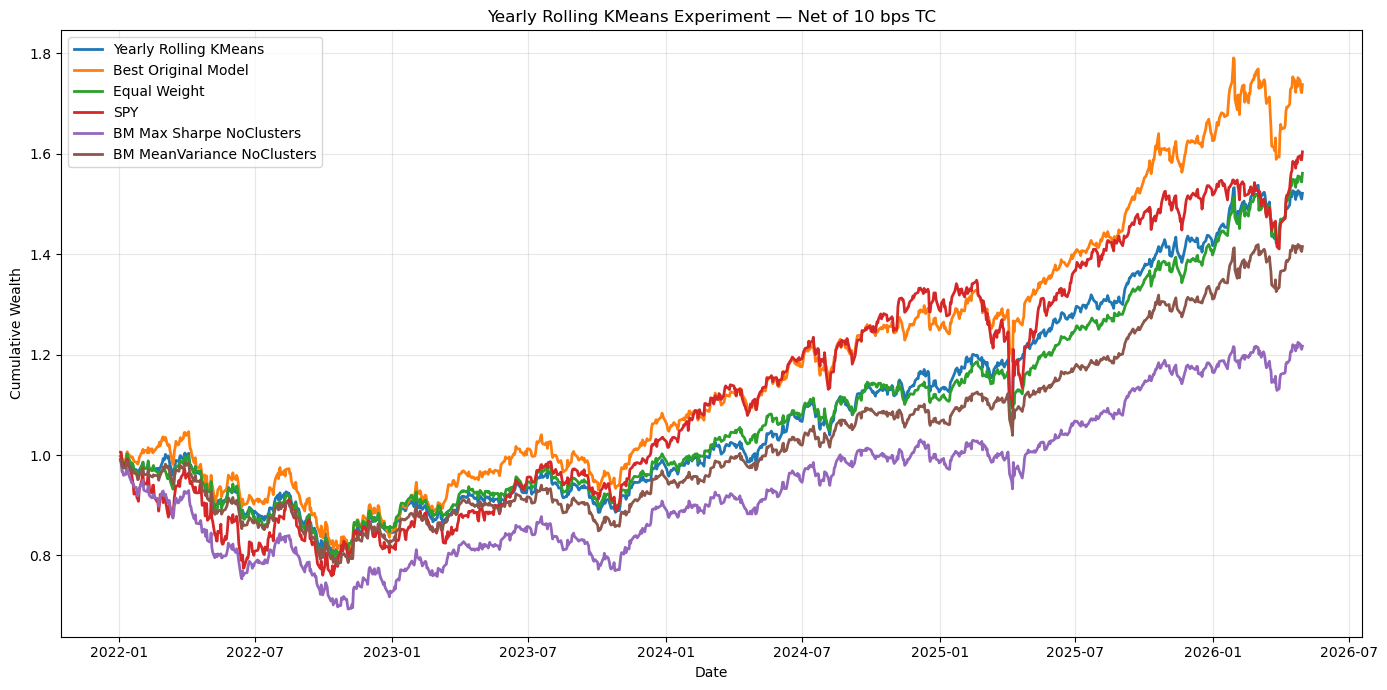

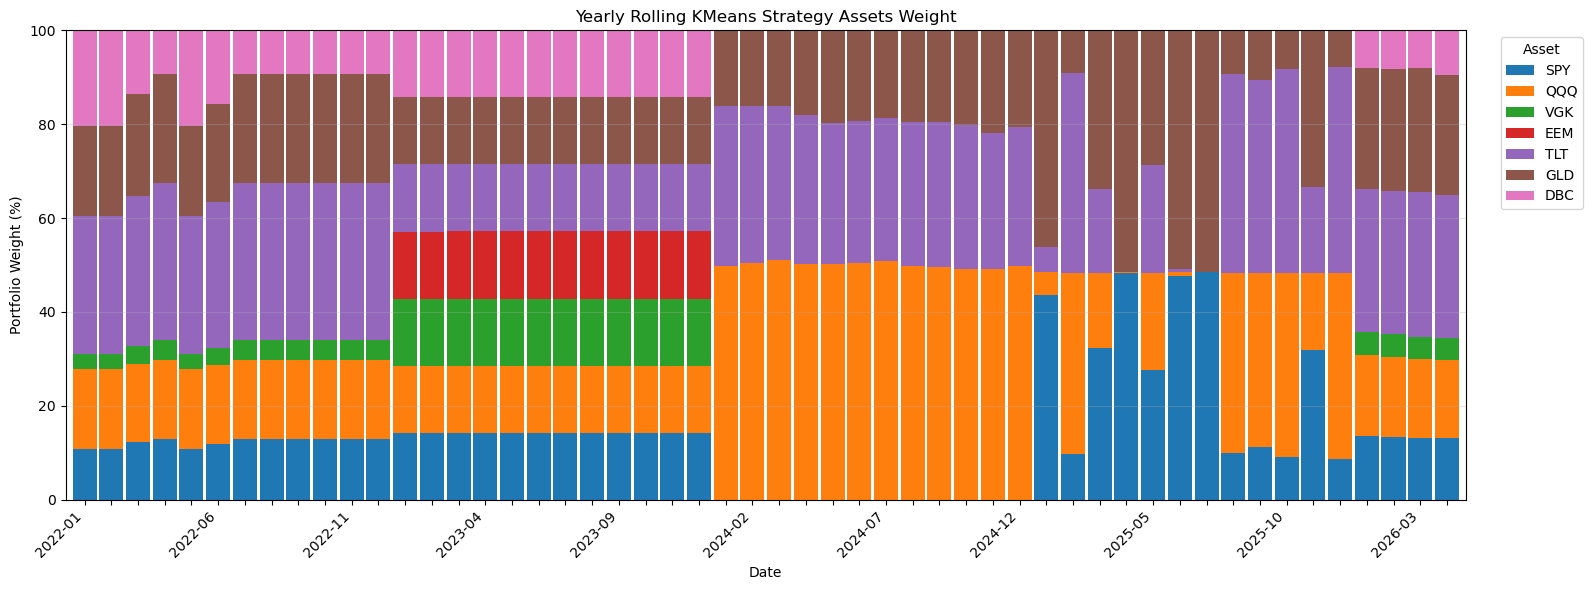

In [19]:


# ============================================================

# 6) PLOT CUMULATIVE WEALTH

# ============================================================

cum_experiment = pd.DataFrame({

    name: (1 + ret).cumprod()

    for name, ret in comparison_experiment.items()

}).dropna()

plt.figure(figsize=(14, 7))

for col in cum_experiment.columns:

    plt.plot(

        cum_experiment.index,

        cum_experiment[col],

        linewidth=2,

        label=col

    )

plt.title("Yearly Rolling KMeans Experiment — Net of 10 bps TC")

plt.xlabel("Date")

plt.ylabel("Cumulative Wealth")

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================

# 7) PLOT WEIGHTS OF YEARLY ROLLING KMEANS

# ============================================================

plot_stacked_weights(

    rolling_kmeans_weights,

    "Yearly Rolling KMeans Strategy Assets Weight"
)

Running Rolling PCA | K=2
Running Rolling PCA | K=3
Running Rolling PCA | K=4
Running Rolling PCA | K=5

ROLLING PCA — OUT-OF-SAMPLE PERFORMANCE — NET OF 10 BPS TRANSACTION COSTS
  Features Clusters                   Strategy  Annual Return  Annual Volatility  Risk-Free Rate  Sharpe Ratio  Alpha Annual  Beta vs QQQ  Alpha t-stat  CAPM R²  VaR 95%  VaR 99%  ES 95%  ES 99%  Max Drawdown  Calmar Ratio
RollingPCA        4              Mean_Variance         0.1464             0.1576          0.0383        0.6858        0.0679       0.3678        1.0300   0.2959  -0.0138  -0.0275 -0.0229 -0.0429       -0.2294        0.6382
RollingPCA        3                 Max_Sharpe         0.1418             0.1524          0.0383        0.6793        0.0529       0.4511        0.9681   0.4755  -0.0145  -0.0260 -0.0216 -0.0359       -0.2670        0.5313
RollingPCA        3              Mean_Variance         0.1171             0.1298          0.0383        0.6072        0.0316       0.4140        0.7427 

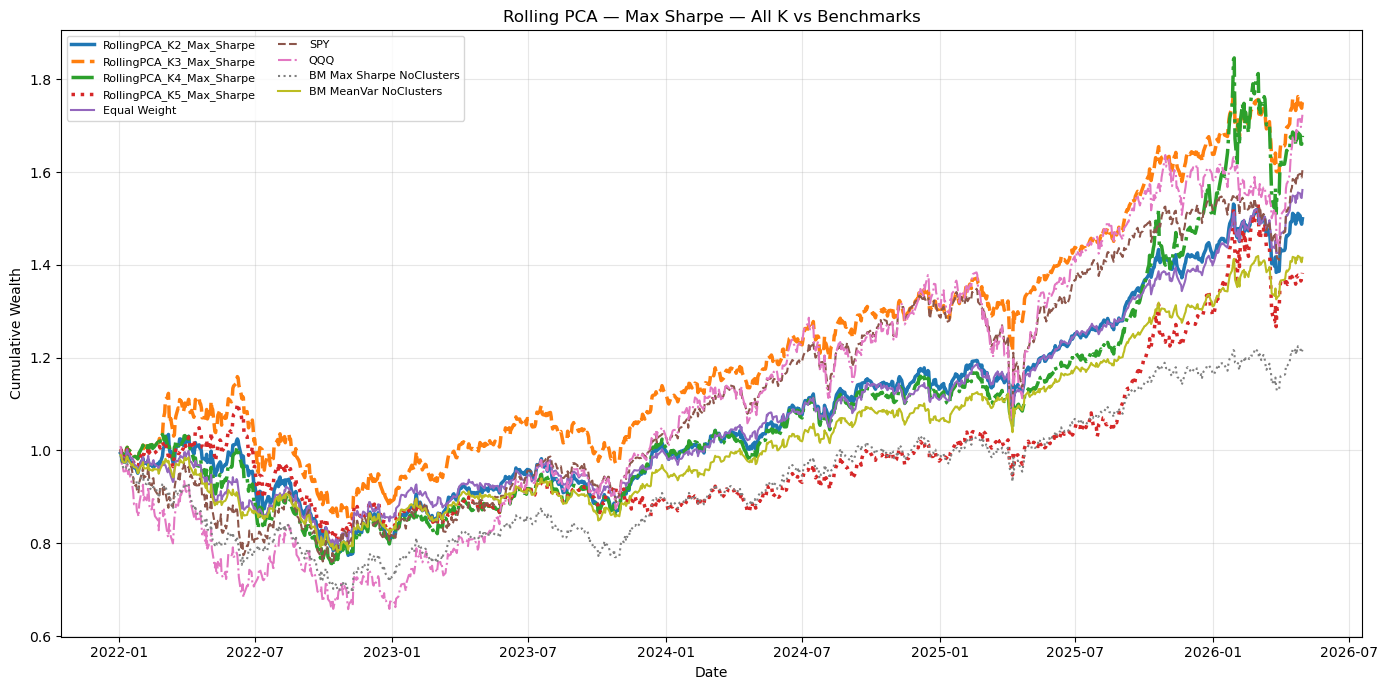

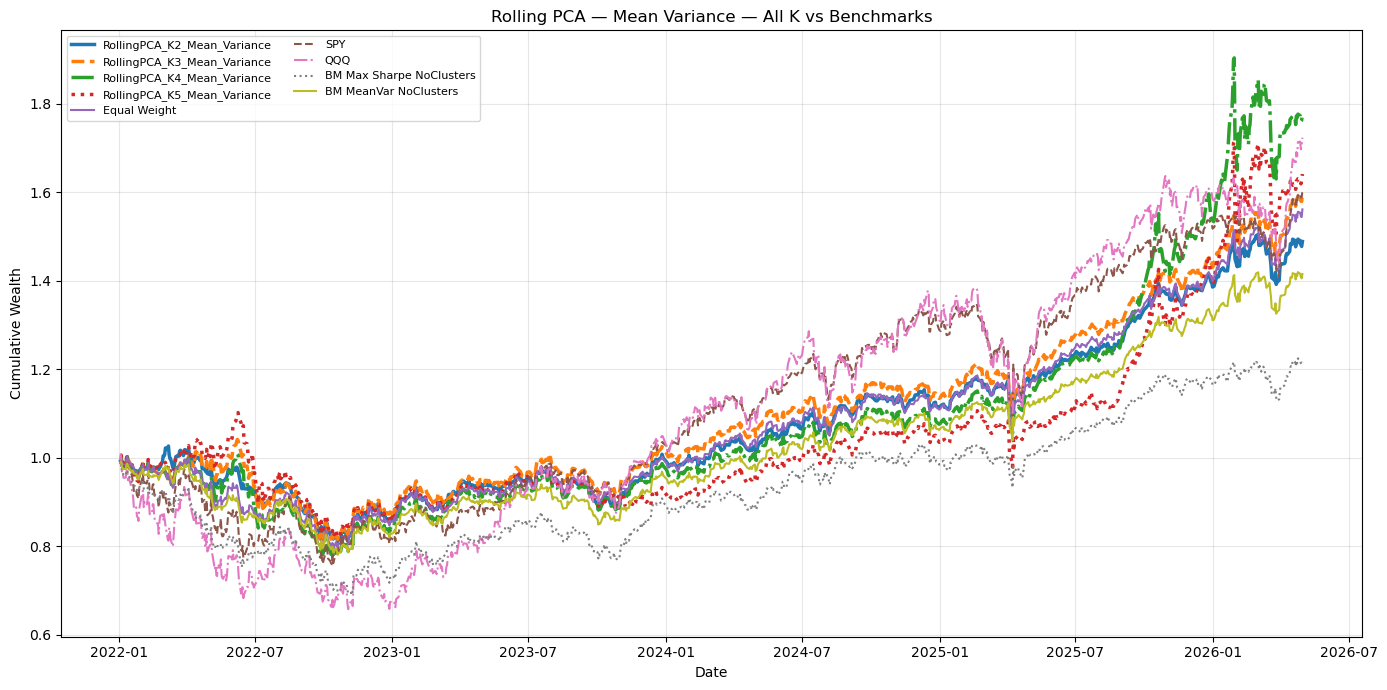

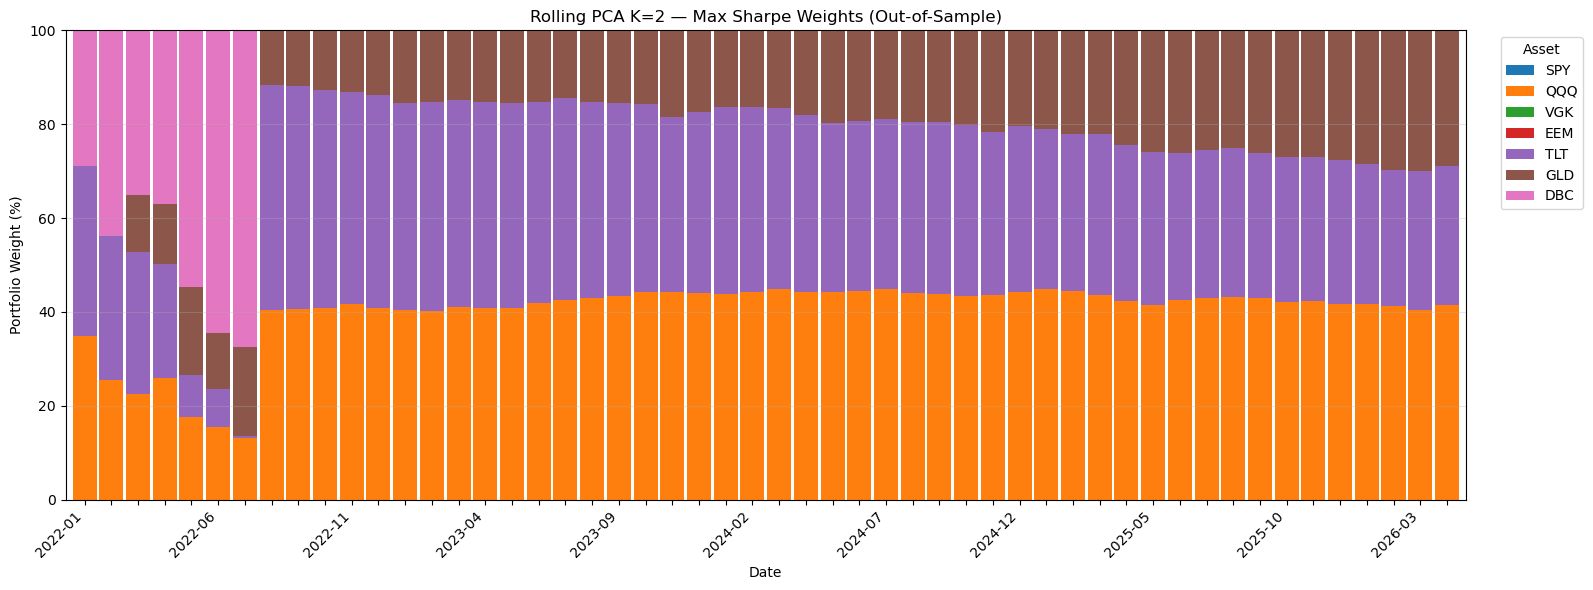

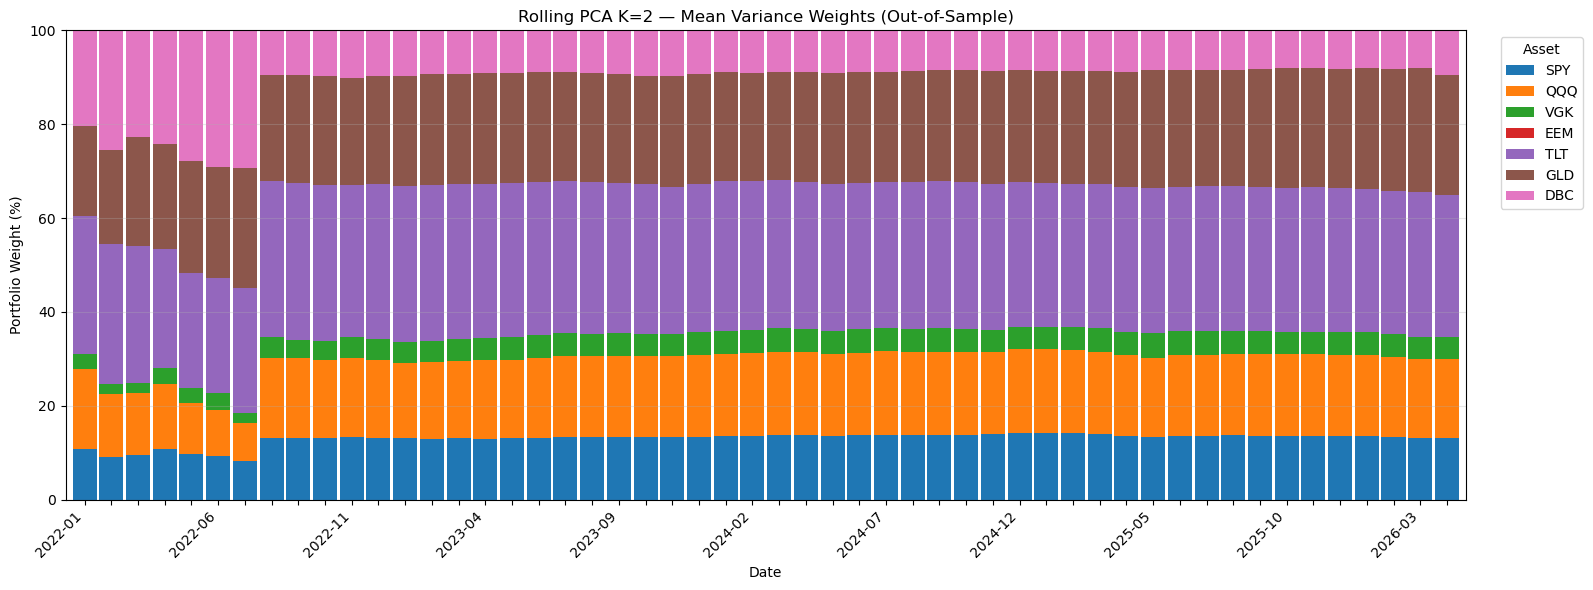

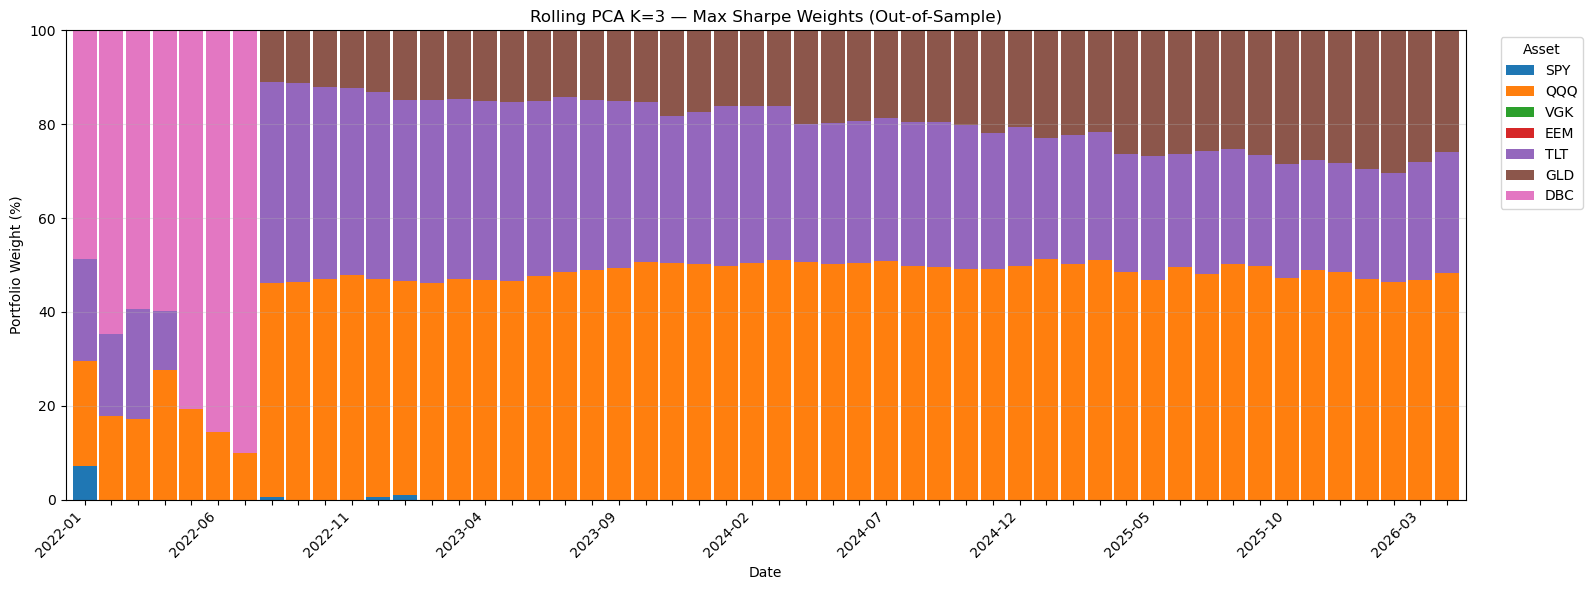

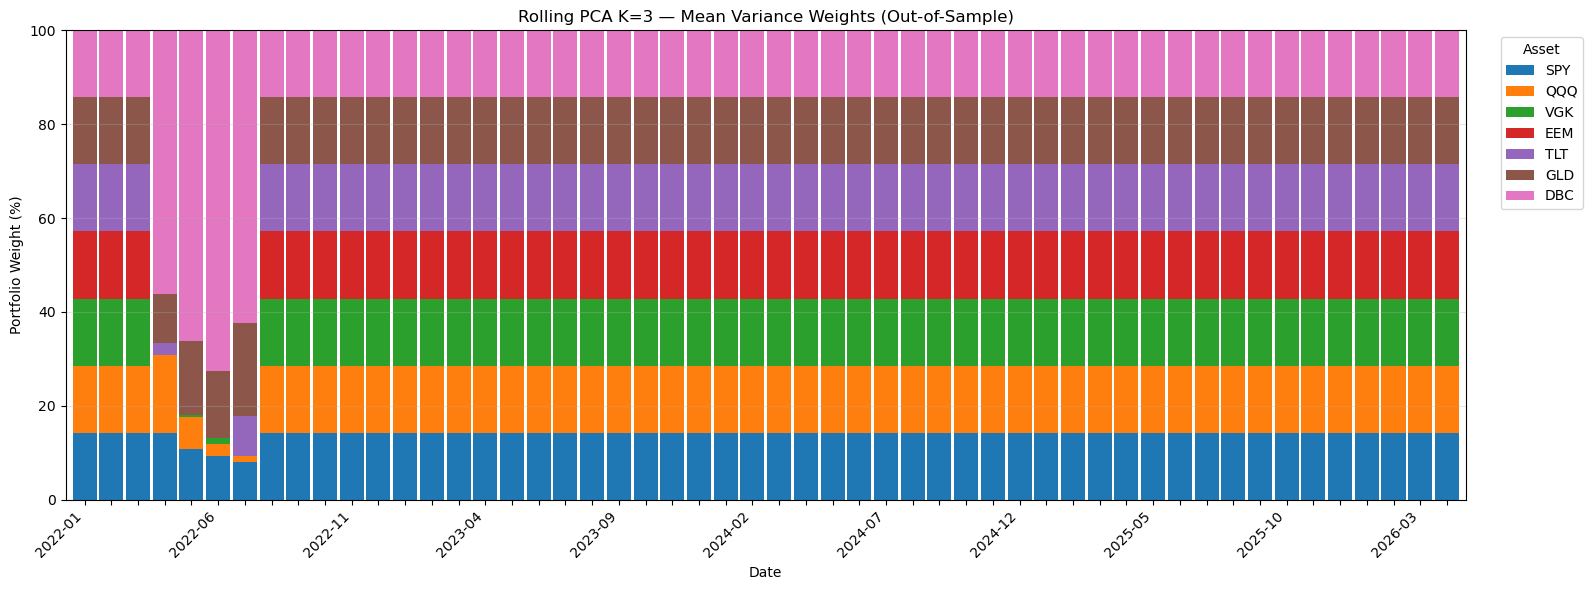

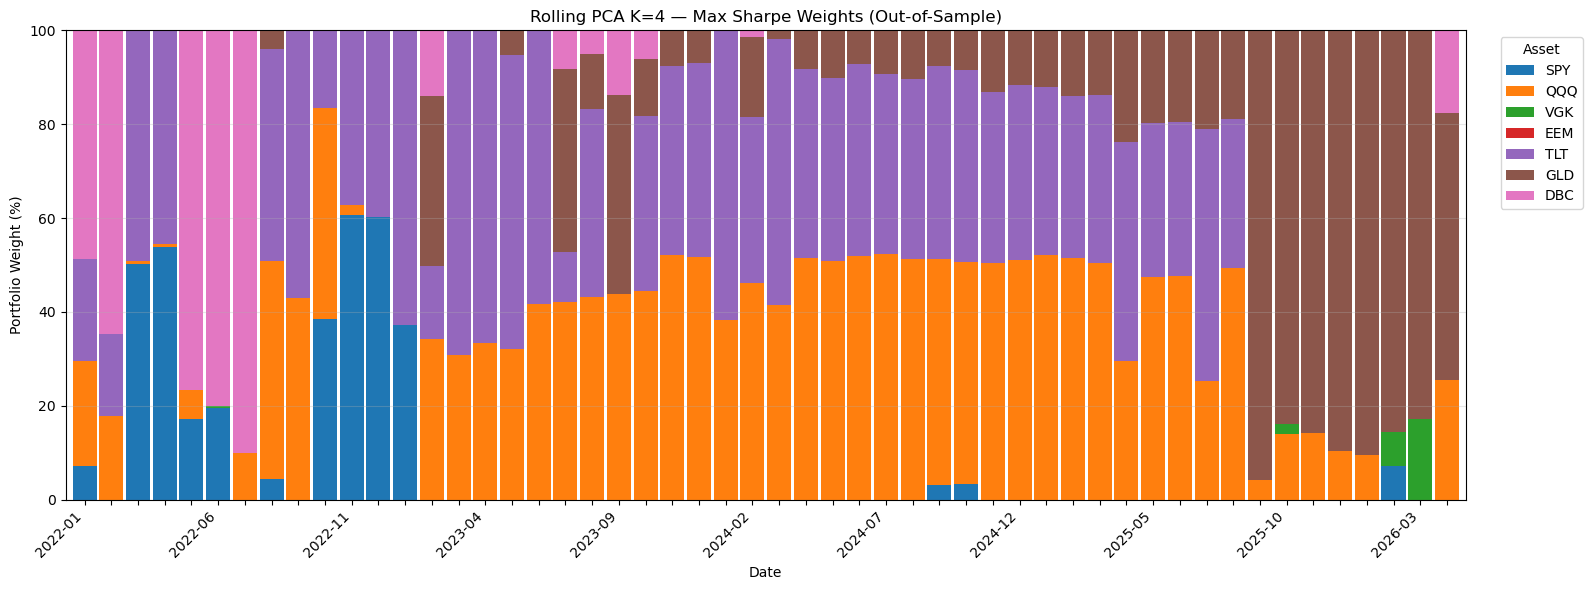

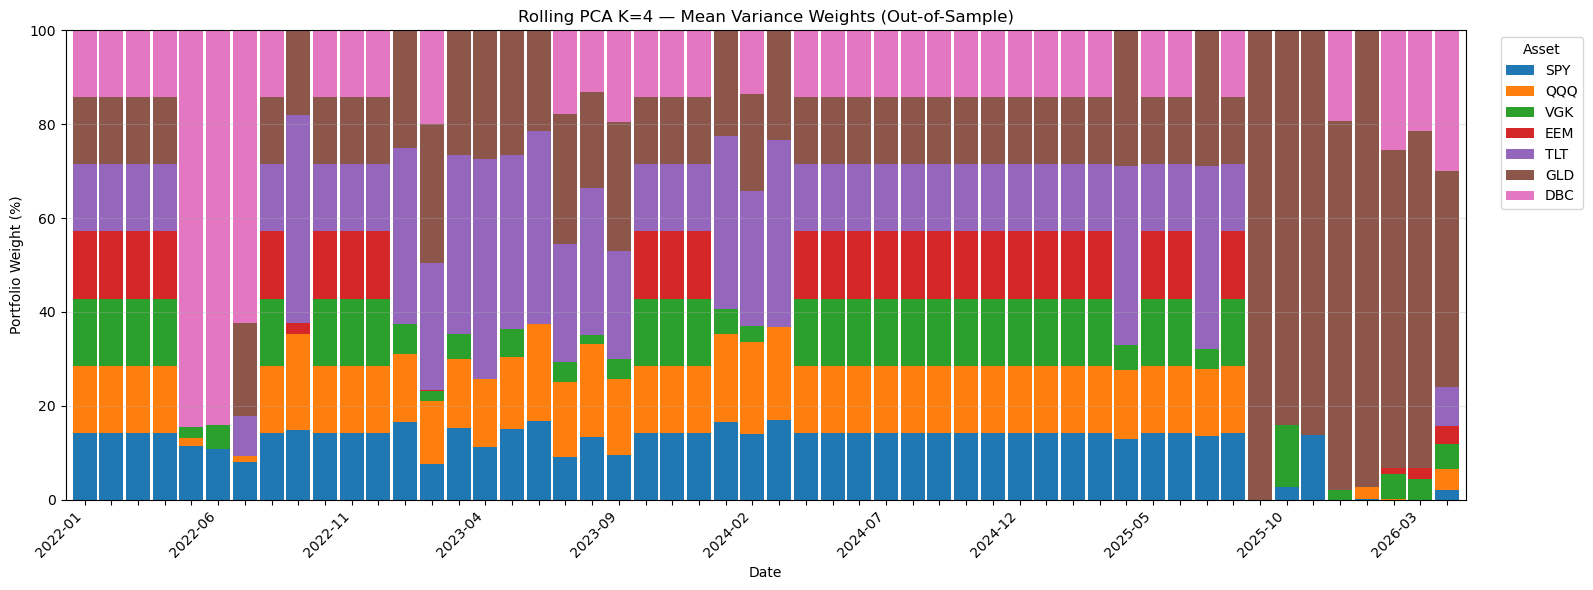

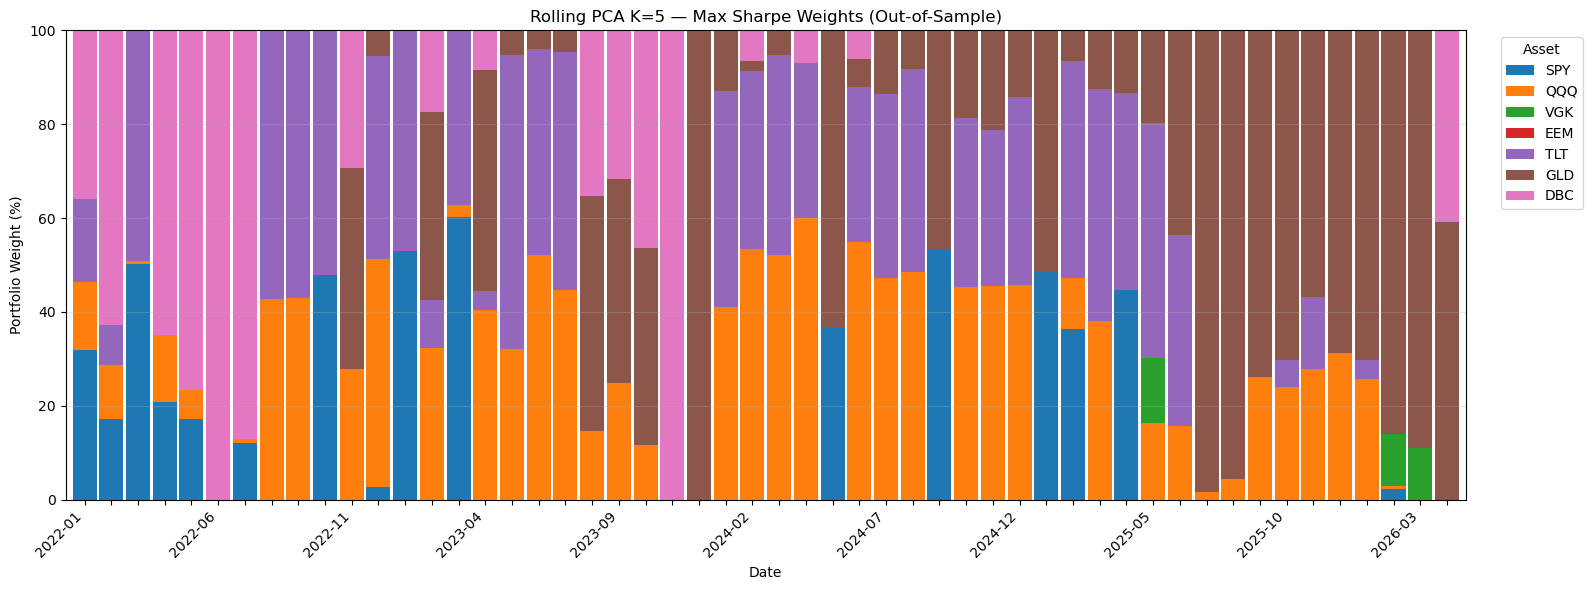

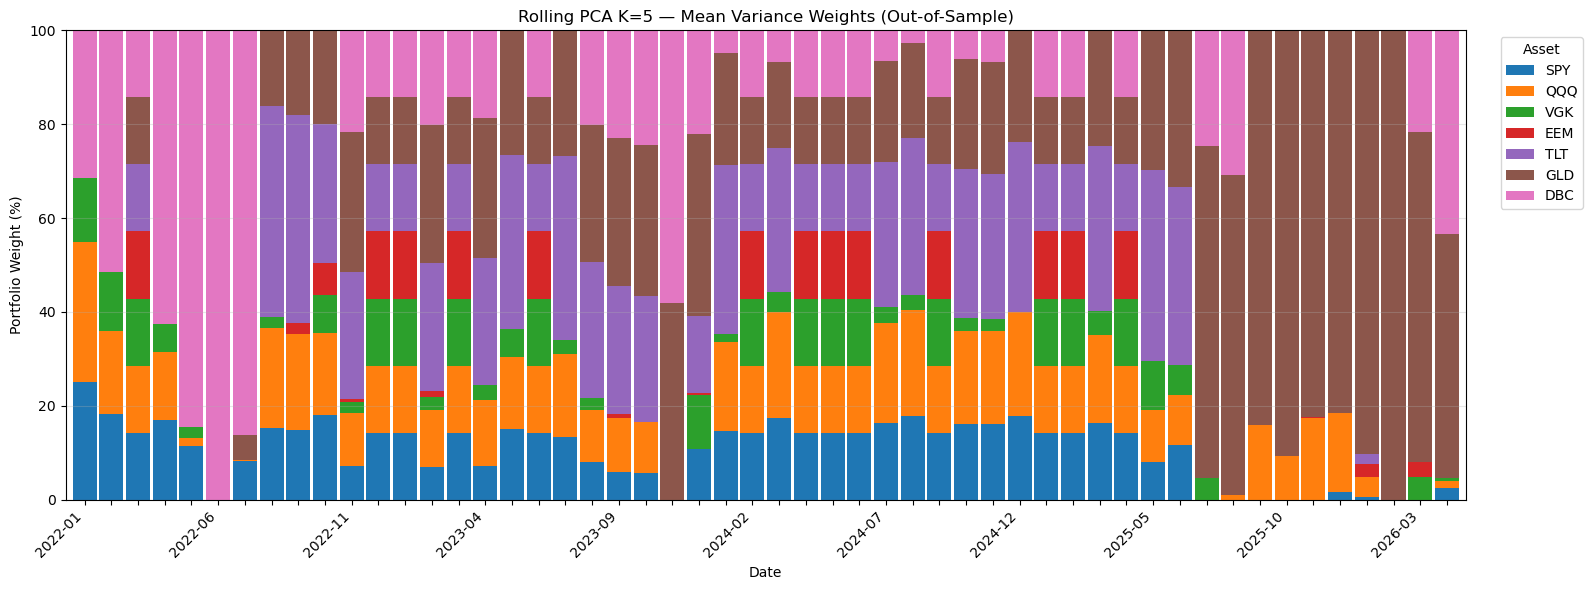

In [20]:
# ============================================================
# ROLLING PCA — MULTI-K EXPERIMENT + UNIFIED PERFORMANCE TABLE
# ============================================================
#
# Per ogni mese t del test set, scaler e PCA vengono rifittati
# usando solo dati disponibili fino a t-1 (expanding window).
# KMeans e LDA sono fittati una volta sola sul training originale
# (per ogni K), per garantire coerenza delle etichette di regime
# nel tempo. Il blocco replica la struttura del loop
# "UNIFIED OUT-OF-SAMPLE PERFORMANCE TABLE" ma limitato alle
# strategie Rolling PCA, per tutti i K in N_CLUSTERS_LIST.
#
# Presuppone che siano già definiti nello script principale:
#   macro, macro_train, macro_test, pca_train, PC_COLS,
#   returns_daily, risky_assets, split_date, N_CLUSTERS_LIST,
#   max_sharpe_ratio, mean_variance_optimization,
#   apply_transaction_costs, performance_metrics,
#   equal_weight_returns, spy_returns, qqq_returns,
#   bm_sharpe_net, bm_mv_net
# ============================================================


def run_rolling_pca(n_clusters, n_components=len(PC_COLS)):
    """
    Esegue la strategia Rolling PCA per un dato numero di cluster K.

    IMPORTANTE: PCA e KMeans vengono rifittati ENTRAMBI ogni mese, sulla
    STESSA finestra di dati disponibili — così i cluster vivono sempre
    nello stesso spazio delle componenti principali usate per quel mese.
    (Versione precedente: KMeans/LDA erano fittati una sola volta sullo
    spazio PCA originale fisso, mentre la PCA veniva rifittata ogni mese;
    il mismatch tra i due spazi produceva assegnazioni di regime rumorose
    e risultati non affidabili — vedi K=5 con Sharpe > 1 spurio.)

    Ritorna i rendimenti giornalieri netti (Max Sharpe e Mean Variance)
    e i relativi pesi giornalieri.
    """

    test_months_rolling = macro_test.index.to_period("M").unique().sort_values()

    weights_sharpe_list = []
    weights_mv_list     = []

    for current_month in test_months_rolling:

        macro_available = macro.loc[macro.index.to_period("M") < current_month].copy()

        scaler_rolling = StandardScaler()
        macro_scaled_rolling = pd.DataFrame(
            scaler_rolling.fit_transform(macro_available),
            columns=macro_available.columns, index=macro_available.index
        )

        pca_rolling = PCA()
        pca_rolling.fit(macro_scaled_rolling)

        pc_available = pd.DataFrame(
            pca_rolling.transform(macro_scaled_rolling),
            columns=[f"PC{i+1}" for i in range(macro_scaled_rolling.shape[1])],
            index=macro_available.index
        )[PC_COLS[:n_components]]

        # KMeans rifittato OGNI MESE, sullo stesso pc_available appena calcolato:
        # coerenza garantita tra spazio di stima e spazio di assegnazione.
        kmeans_rolling = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        clusters_available = kmeans_rolling.fit_predict(pc_available)
        regime_current = int(clusters_available[-1])

        returns_available = returns_daily.loc[
            returns_daily.index.to_period("M") < current_month, risky_assets + ["BIL"]
        ].copy()
        returns_available["month"] = returns_available.index.to_period("M")

        cluster_series = pd.Series(clusters_available, index=macro_available.index)
        cluster_series.index = cluster_series.index.to_period("M")

        returns_with_regime = returns_available.merge(
            cluster_series.rename("cluster"), left_on="month", right_index=True, how="left"
        ).dropna()

        regime_data = returns_with_regime[returns_with_regime["cluster"] == regime_current]
        if len(regime_data) < 20:
            regime_data = returns_with_regime

        r   = regime_data[risky_assets]
        mu  = r.mean()
        cov = r.cov()
        rf  = regime_data["BIL"].mean()

        w_sharpe = max_sharpe_ratio(mu, cov, rf)
        w_mv     = mean_variance_optimization(mu, cov)

        days_month = returns_daily.loc[
            returns_daily.index.to_period("M") == current_month
        ].index

        weights_sharpe_list.append(pd.DataFrame(
            np.tile(w_sharpe, (len(days_month), 1)), index=days_month, columns=risky_assets
        ))
        weights_mv_list.append(pd.DataFrame(
            np.tile(w_mv, (len(days_month), 1)), index=days_month, columns=risky_assets
        ))

    weights_sharpe = pd.concat(weights_sharpe_list).sort_index()
    weights_mv     = pd.concat(weights_mv_list).sort_index()

    ret_assets = returns_daily.loc[weights_sharpe.index, risky_assets]

    gross_sharpe = (weights_sharpe * ret_assets).sum(axis=1)
    gross_mv     = (weights_mv     * ret_assets).sum(axis=1)

    net_sharpe = apply_transaction_costs(gross_sharpe, weights_sharpe)
    net_mv     = apply_transaction_costs(gross_mv,     weights_mv)

    return net_sharpe, weights_sharpe, net_mv, weights_mv


# ============================================================
# LOOP SU TUTTI I K — ROLLING PCA
# ============================================================

all_returns_rolling_pca = {}
all_weights_rolling_pca = {}

for n_clusters in N_CLUSTERS_LIST:
    print(f"Running Rolling PCA | K={n_clusters}")

    net_sharpe, w_sharpe, net_mv, w_mv = run_rolling_pca(n_clusters)

    all_returns_rolling_pca[f"RollingPCA_K{n_clusters}_Max_Sharpe"]    = net_sharpe
    all_weights_rolling_pca[f"RollingPCA_K{n_clusters}_Max_Sharpe"]    = w_sharpe

    all_returns_rolling_pca[f"RollingPCA_K{n_clusters}_Mean_Variance"] = net_mv
    all_weights_rolling_pca[f"RollingPCA_K{n_clusters}_Mean_Variance"] = w_mv


# ============================================================
# UNIFIED OUT-OF-SAMPLE PERFORMANCE TABLE — ROLLING PCA
# ============================================================

perf_records_rolling = []

for key, net_ret in all_returns_rolling_pca.items():
    parts      = key.split("_")
    feature    = parts[0]                       # "RollingPCA"
    n_clusters = int(parts[1].replace("K", ""))
    strategy   = "_".join(parts[2:])             # "Max_Sharpe" / "Mean_Variance"

    rf        = returns_daily.loc[net_ret.index, "BIL"]
    benchmark = returns_daily.loc[net_ret.index, "QQQ"]
    metrics   = performance_metrics(net_ret, rf, benchmark_returns=benchmark)

    perf_records_rolling.append({
        "Features":  feature,
        "Clusters":  n_clusters,
        "Strategy":  strategy,
        **metrics.to_dict()
    })

for name, ret in [
    ("Equal Weight",               equal_weight_returns),
    ("SPY",                        spy_returns),
    ("QQQ",                        qqq_returns),
    ("BM_Max_Sharpe_NoClusters",   bm_sharpe_net),
    ("BM_MeanVariance_NoClusters", bm_mv_net),
]:
    common_idx = ret.index.intersection(next(iter(all_returns_rolling_pca.values())).index)
    ret_aligned = ret.loc[common_idx]
    rf          = returns_daily.loc[common_idx, "BIL"]
    benchmark   = returns_daily.loc[common_idx, "QQQ"]
    metrics     = performance_metrics(ret_aligned, rf, benchmark_returns=benchmark)
    perf_records_rolling.append({"Features": "Benchmark", "Clusters": "-", "Strategy": name, **metrics.to_dict()})

rolling_pca_performance_df = (
    pd.DataFrame(perf_records_rolling)
    .sort_values(by="Sharpe Ratio", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("ROLLING PCA — OUT-OF-SAMPLE PERFORMANCE — NET OF 10 BPS TRANSACTION COSTS")
print("=" * 80)
print(rolling_pca_performance_df.to_string(index=False))


# ============================================================
# ROLLING PCA — CUMULATIVE WEALTH PLOT (TUTTI I K)
# ============================================================
#
# Un grafico per ogni ottimizzatore (Max Sharpe / Mean Variance),
# con una linea per ciascun K, più i benchmark di confronto.
# ============================================================

benchmark_series_for_plot = {
    "Equal Weight":              equal_weight_returns,
    "SPY":                       spy_returns,
    "QQQ":                       qqq_returns,
    "BM Max Sharpe NoClusters":  bm_sharpe_net,
    "BM MeanVar NoClusters":     bm_mv_net,
}

for optimizer_label in ["Max_Sharpe", "Mean_Variance"]:

    plot_series_rolling = {
        key: ret for key, ret in all_returns_rolling_pca.items()
        if key.endswith(optimizer_label)
    }

    # allinea i benchmark all'indice comune delle strategie rolling
    common_idx = next(iter(plot_series_rolling.values())).index
    for name, ret in benchmark_series_for_plot.items():
        plot_series_rolling[name] = ret.loc[ret.index.intersection(common_idx)]

    cum_rolling_all_k = pd.DataFrame({
        name: (1 + ret).cumprod() for name, ret in plot_series_rolling.items()
    }).dropna()

    plt.figure(figsize=(14, 7))
    styles = ["-", "--", "-.", ":", "-", "--", "-.", ":", "-", "--"]
    for i, col in enumerate(cum_rolling_all_k.columns):
        lw = 2.5 if "RollingPCA" in col else 1.5
        plt.plot(cum_rolling_all_k.index, cum_rolling_all_k[col],
                  linewidth=lw, linestyle=styles[i % len(styles)], label=col)
    plt.title(f"Rolling PCA — {optimizer_label.replace('_', ' ')} — All K vs Benchmarks")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Wealth")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


# ============================================================
# ROLLING PCA — WEIGHTS PLOTS (TUTTI I K)
# ============================================================
#
# Un plot dei pesi impilati per ciascuna combinazione
# (K, optimizer), riusando plot_stacked_weights già definita
# nello script principale.
# ============================================================

for key, weights_df in all_weights_rolling_pca.items():
    parts        = key.split("_")
    n_clusters   = parts[1].replace("K", "")
    strategy_lbl = "_".join(parts[2:]).replace("_", " ")

    plot_stacked_weights(
        weights_df,
        f"Rolling PCA K={n_clusters} — {strategy_lbl} Weights (Out-of-Sample)"
    )
    


YEARLY ROLLING K-MEANS — OUT-OF-SAMPLE PERFORMANCE — NET OF 10 BPS TC
 Features Clusters                       Strategy  Annual Return  Annual Volatility  Risk-Free Rate  Sharpe Ratio  Alpha Annual  Beta vs QQQ  Alpha t-stat  CAPM R²  VaR 95%  VaR 99%  ES 95%  ES 99%  Max Drawdown  Calmar Ratio
      PCA        3           Expanding_Max_Sharpe         0.1290             0.1398          0.0383        0.6488        0.0353       0.4861        0.8779   0.6568  -0.0143  -0.0222 -0.0193 -0.0280       -0.2304        0.5598
      RAW        3        Expanding_Mean_Variance         0.1166             0.1250          0.0383        0.6266        0.0288       0.4331        0.7984   0.6517  -0.0123  -0.0204 -0.0174 -0.0263       -0.2058        0.5667
      RAW        3           Static_Mean_Variance         0.1152             0.1251          0.0383        0.6152        0.0272       0.4352        0.7588   0.6573  -0.0125  -0.0204 -0.0174 -0.0263       -0.2058        0.5600
Benchmark        -       

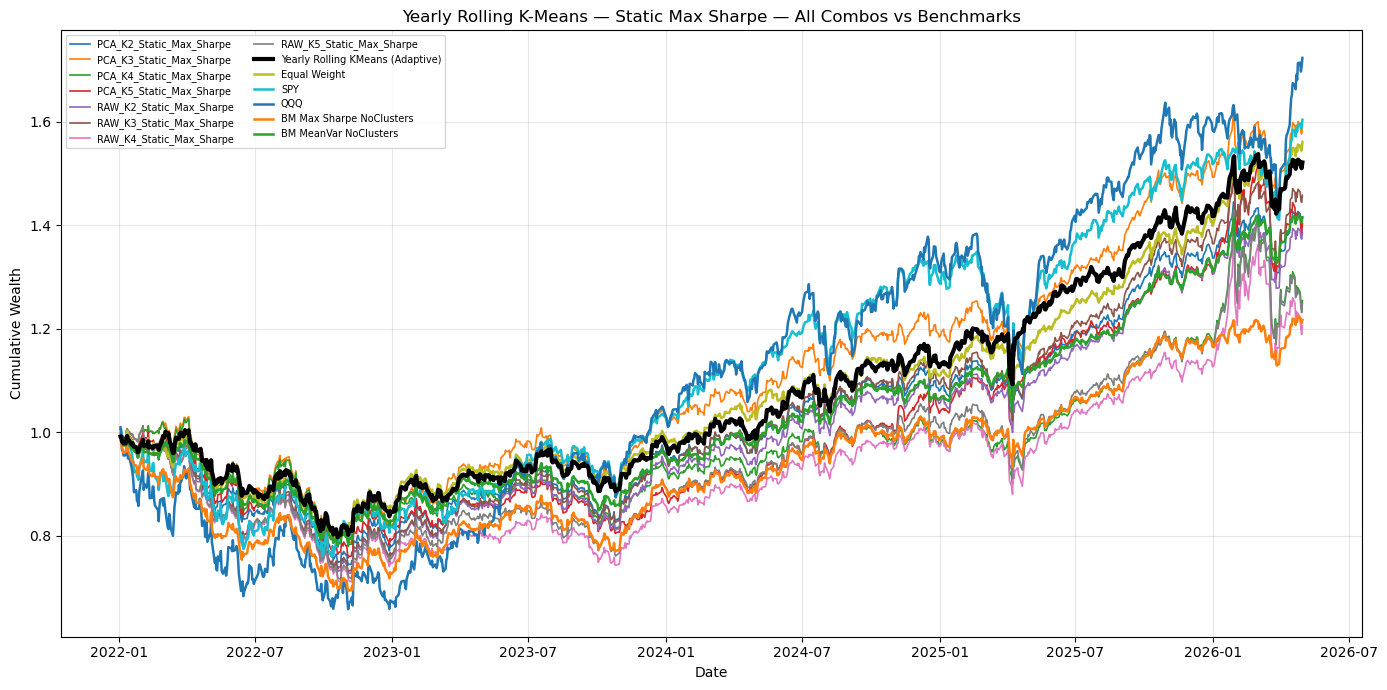

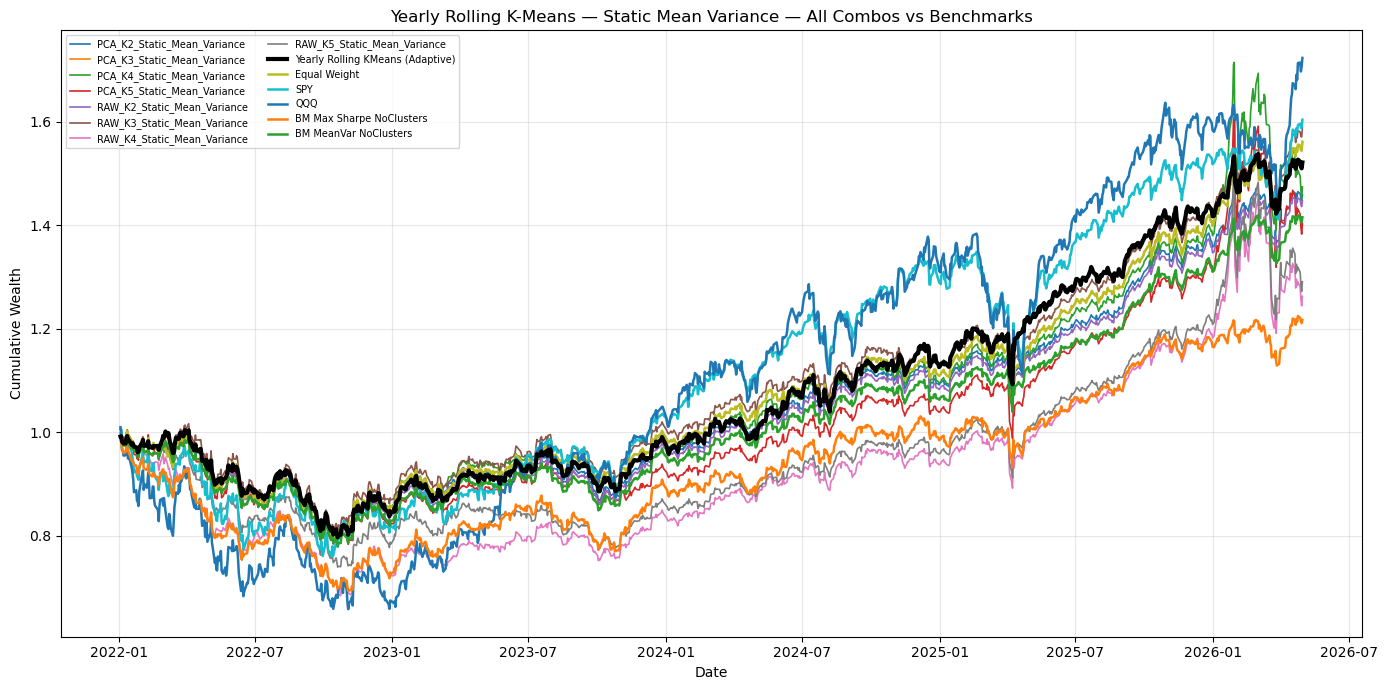

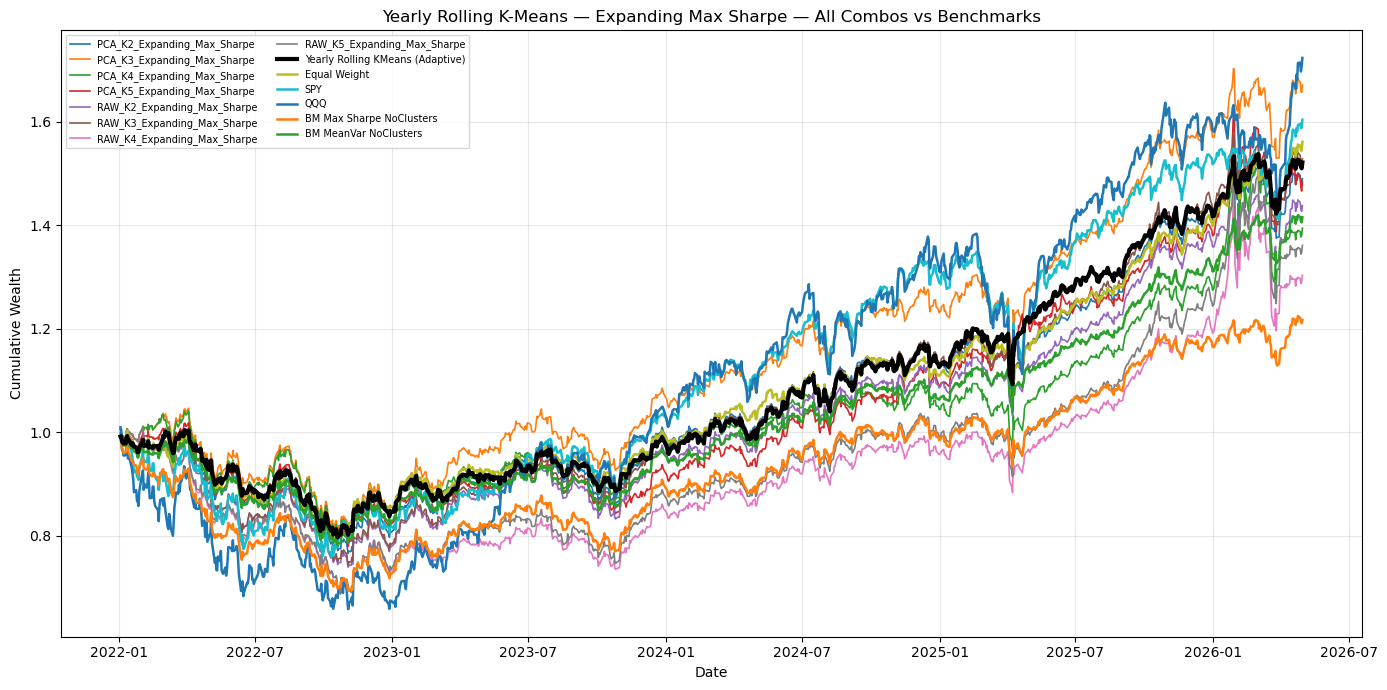

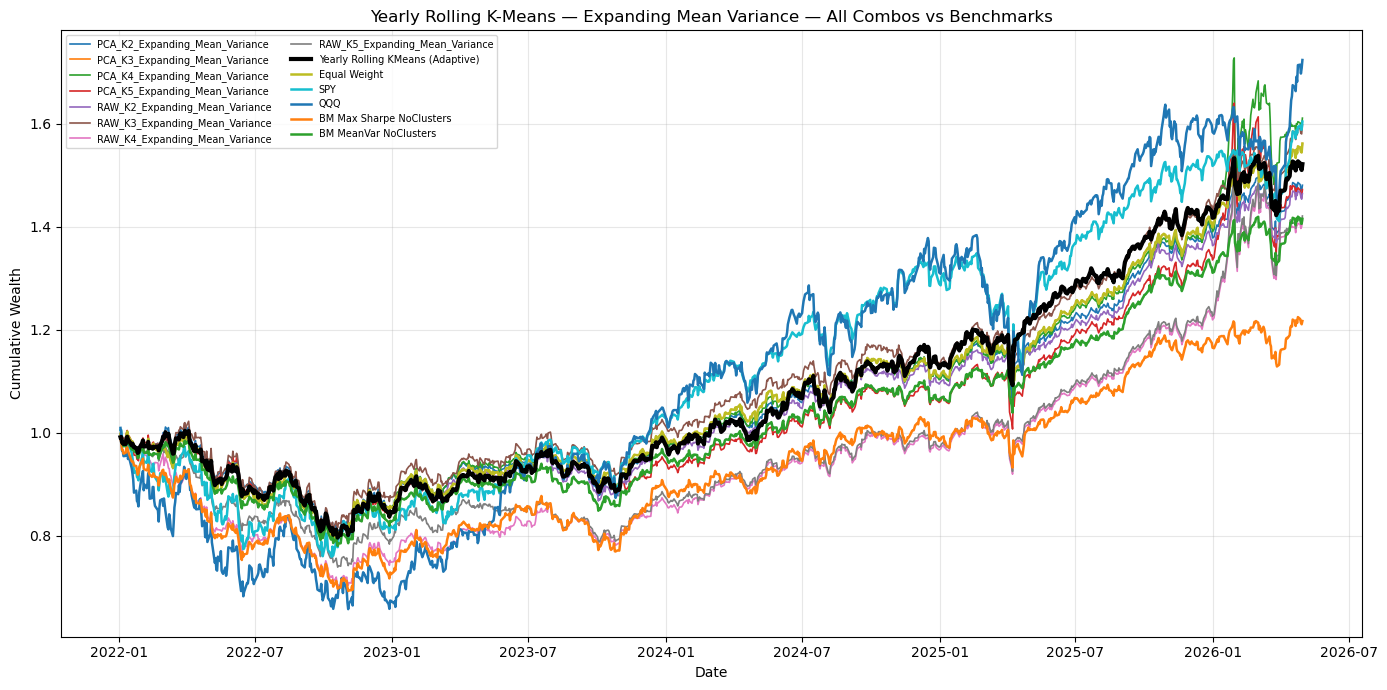

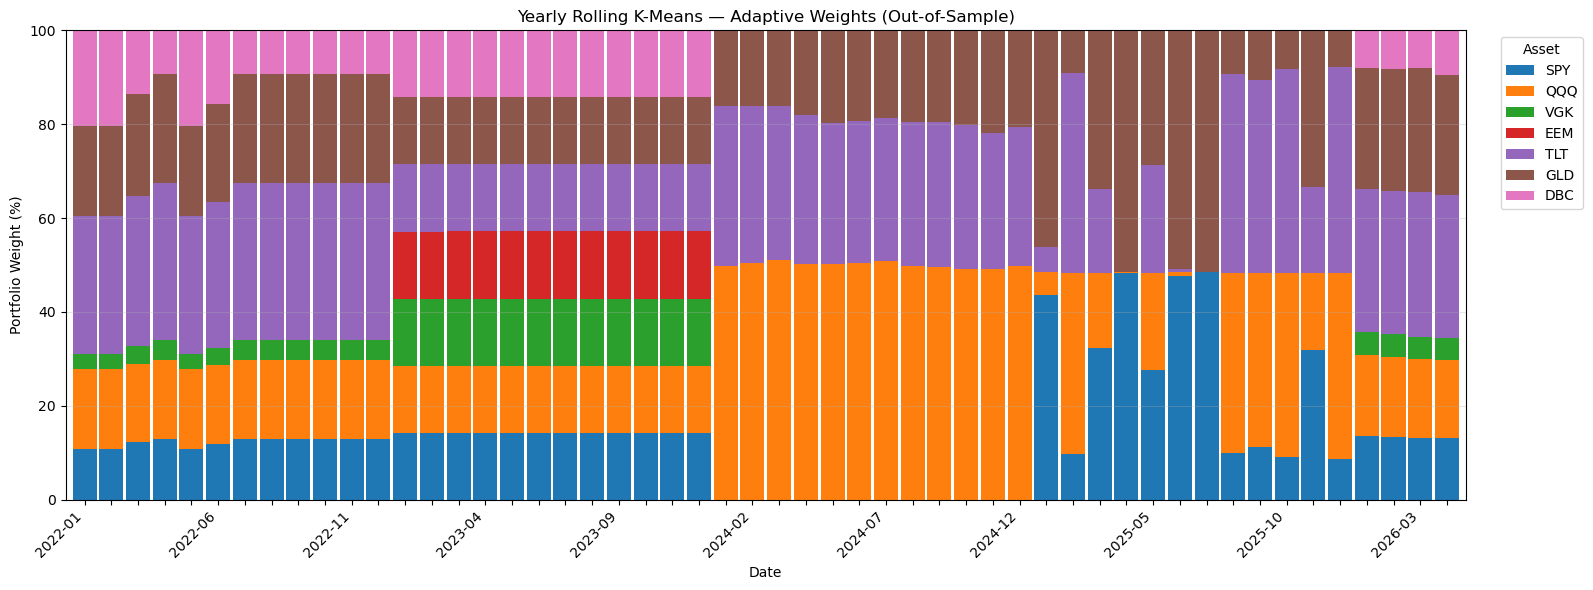

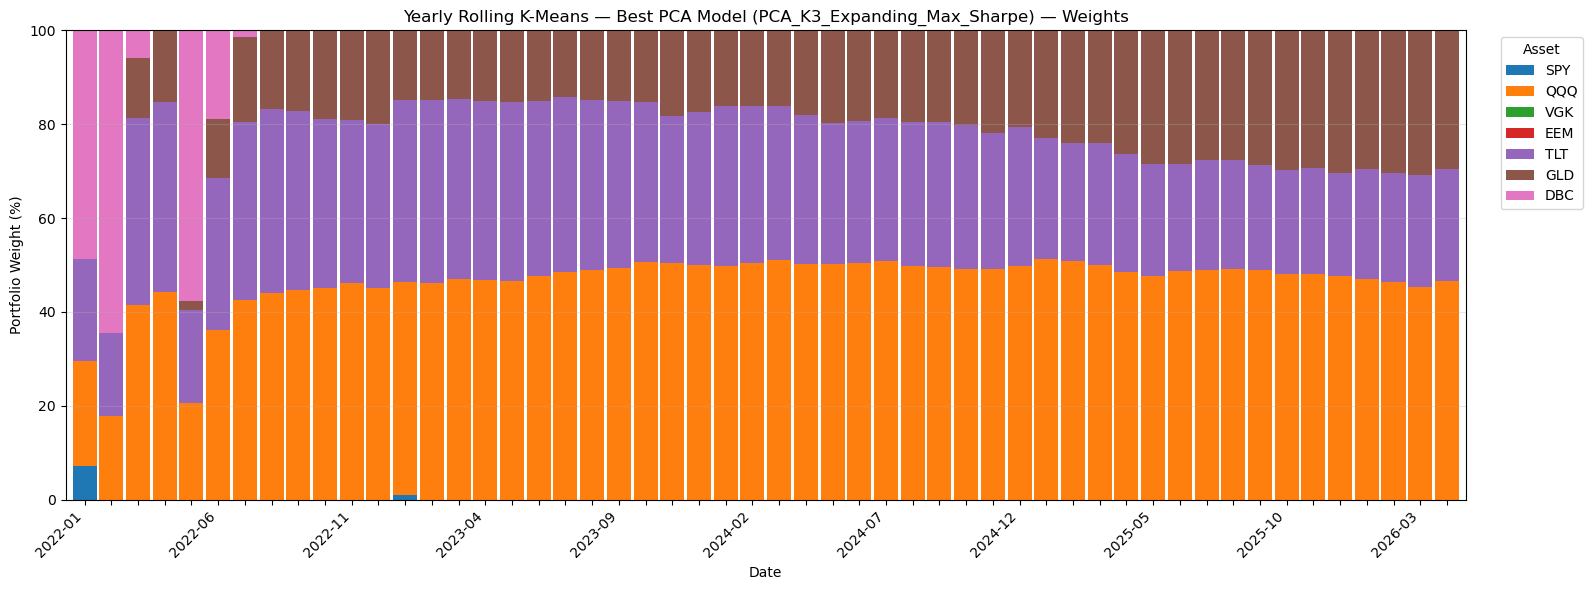

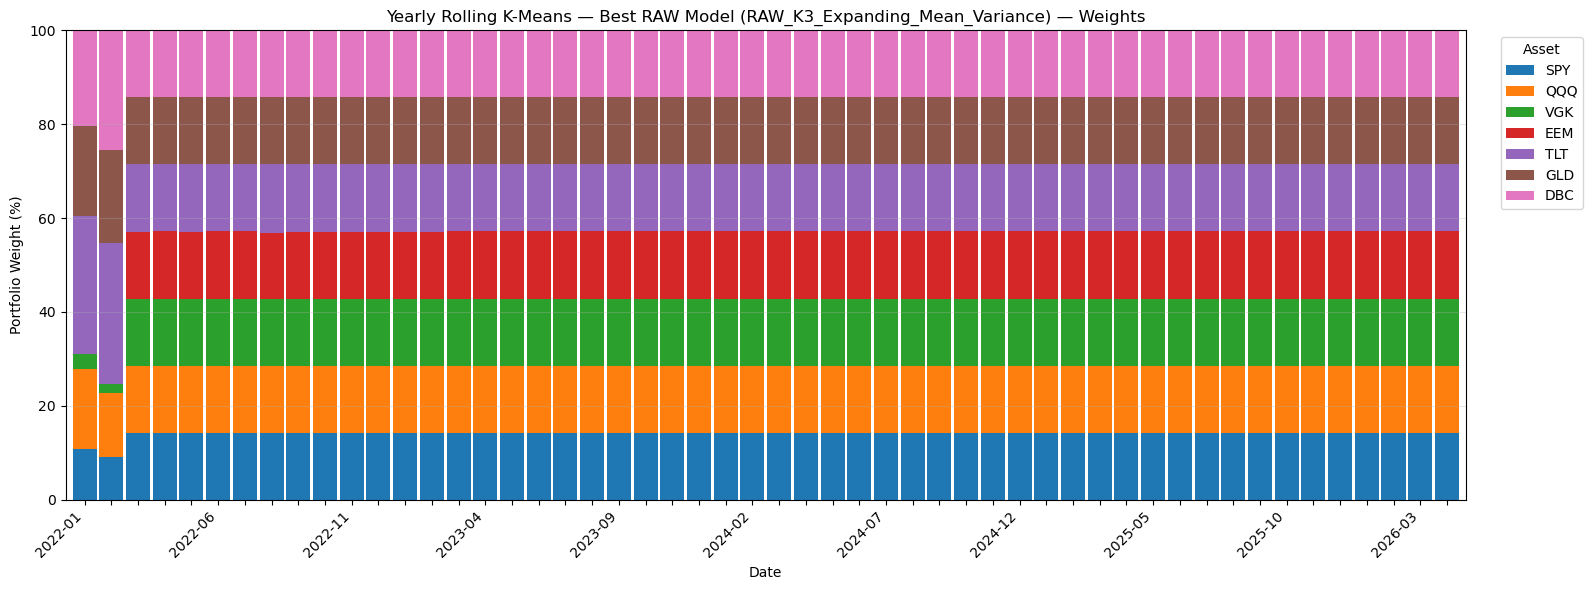

In [21]:
# ============================================================
# YEARLY ROLLING K-MEANS — UNIFIED PERFORMANCE TABLE
# ============================================================
#
# L'esperimento "Yearly Rolling KMeans" rifitta ogni anno
# scaler/PCA/KMeans/LDA su dati disponibili fino a t-1 e calcola,
# per quell'anno, TUTTE le combinazioni (Feature, K, Strategy)
# candidate — sono già tutte disponibili in all_returns_yearly
# con chiave "{year}_{feature}_K{n}_{strategy}".
#
# Per costruire una tabella di performance "full period" analoga
# a quella di Rolling PCA, ricostruiamo per ciascuna combinazione
# fissa (Feature, K, Strategy) la serie di rendimenti sull'intero
# periodo di test, concatenando anno per anno i rendimenti che
# quella combinazione avrebbe prodotto (anche se non è stata
# selezionata come "best" in quell'anno). In più includiamo come
# riga a parte la strategia realmente adattiva selezionata
# (rolling_kmeans_returns), che cambia combinazione di anno in anno.
#
# Presuppone che siano già definiti nello script principale:
#   all_returns_yearly, all_weights_yearly, yearly_selection_df,
#   rolling_kmeans_returns, rolling_kmeans_weights,
#   returns_daily, performance_metrics, plot_stacked_weights,
#   equal_weight_returns, spy_returns, qqq_returns,
#   bm_sharpe_net, bm_mv_net
# ============================================================


# ============================================================
# 1) RICOSTRUZIONE SERIE FULL-PERIOD PER OGNI COMBINAZIONE FISSA
# ============================================================

combo_returns_yearly = {}
combo_weights_yearly = {}

for full_key, ret in all_returns_yearly.items():
    year_str, combo_key = full_key.split("_", 1)   # "2022_PCA_K3_Expanding_Max_Sharpe" -> combo_key = "PCA_K3_Expanding_Max_Sharpe"
    combo_returns_yearly.setdefault(combo_key, []).append(ret)

for full_key, wts in all_weights_yearly.items():
    year_str, combo_key = full_key.split("_", 1)
    combo_weights_yearly.setdefault(combo_key, []).append(wts)

combo_weights_full = {
    key: pd.concat(parts).sort_index()
    for key, parts in combo_weights_yearly.items()
}

combo_returns_full = {}

for key, weights in combo_weights_full.items():

    ret_assets = returns_daily.loc[
        weights.index,
        risky_assets
    ]

    gross_ret = (
        weights * ret_assets
    ).sum(axis=1)

    net_ret = apply_transaction_costs(
        portfolio_returns=gross_ret,
        weights=weights,
        tc_bps=TC_BPS
    )

    combo_returns_full[key] = net_ret


# ============================================================
# 2) UNIFIED OUT-OF-SAMPLE PERFORMANCE TABLE
# ============================================================

perf_records_yearly = []

for combo_key, net_ret in combo_returns_full.items():
    parts      = combo_key.split("_")
    feature    = parts[0]
    n_clusters = int(parts[1].replace("K", ""))
    strategy   = "_".join(parts[2:])

    rf        = returns_daily.loc[net_ret.index, "BIL"]
    benchmark = returns_daily.loc[net_ret.index, "QQQ"]
    metrics   = performance_metrics(net_ret, rf, benchmark_returns=benchmark)

    perf_records_yearly.append({
        "Features":  feature,
        "Clusters":  n_clusters,
        "Strategy":  strategy,
        **metrics.to_dict()
    })

# --- Riga a parte: la strategia realmente adattiva (selezione anno per anno) ---
rf_adaptive        = returns_daily.loc[rolling_kmeans_returns.index, "BIL"]
benchmark_adaptive = returns_daily.loc[rolling_kmeans_returns.index, "QQQ"]
metrics_adaptive   = performance_metrics(rolling_kmeans_returns, rf_adaptive, benchmark_returns=benchmark_adaptive)

perf_records_yearly.append({
    "Features": "Adaptive",
    "Clusters": "-",
    "Strategy": "Yearly_Rolling_KMeans_Selected",
    **metrics_adaptive.to_dict()
})

# --- Benchmark rows, allineati all'indice della strategia adattiva ---
for name, ret in [
    ("Equal Weight",               equal_weight_returns),
    ("SPY",                        spy_returns),
    ("QQQ",                        qqq_returns),
    ("BM_Max_Sharpe_NoClusters",   bm_sharpe_net),
    ("BM_MeanVariance_NoClusters", bm_mv_net),
]:
    common_idx  = ret.index.intersection(rolling_kmeans_returns.index)
    ret_aligned = ret.loc[common_idx]
    rf          = returns_daily.loc[common_idx, "BIL"]
    benchmark   = returns_daily.loc[common_idx, "QQQ"]
    metrics     = performance_metrics(ret_aligned, rf, benchmark_returns=benchmark)
    perf_records_yearly.append({"Features": "Benchmark", "Clusters": "-", "Strategy": name, **metrics.to_dict()})

yearly_rolling_performance_df = (
    pd.DataFrame(perf_records_yearly)
    .sort_values(by="Sharpe Ratio", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("YEARLY ROLLING K-MEANS — OUT-OF-SAMPLE PERFORMANCE — NET OF 10 BPS TC")
print("=" * 80)
print(yearly_rolling_performance_df.to_string(index=False))


# ============================================================
# 3) CUMULATIVE WEALTH PLOT (TUTTE LE COMBINAZIONI)
# ============================================================
#
# Un grafico per ogni ottimizzatore (Max Sharpe / Mean Variance),
# un grafico per ogni approccio di ribilanciamento (Static / Expanding),
# con una linea per ciascuna combinazione (Feature, K), più i
# benchmark e la strategia adattiva evidenziata in nero.
# ============================================================

benchmark_series_for_plot = {
    "Equal Weight":              equal_weight_returns,
    "SPY":                       spy_returns,
    "QQQ":                       qqq_returns,
    "BM Max Sharpe NoClusters":  bm_sharpe_net,
    "BM MeanVar NoClusters":     bm_mv_net,
}

rebal_labels    = ["Static", "Expanding"]
optimizer_labels = ["Max_Sharpe", "Mean_Variance"]

for rebal_label in rebal_labels:
    for optimizer_label in optimizer_labels:

        suffix = f"{rebal_label}_{optimizer_label}"
        plot_series_yearly = {
            key: ret for key, ret in combo_returns_full.items()
            if key.endswith(suffix)
        }
        if not plot_series_yearly:
            continue

        common_idx = next(iter(plot_series_yearly.values())).index

        # aggiungi la strategia adattiva (allineata) e i benchmark
        plot_series_yearly["Yearly Rolling KMeans (Adaptive)"] = rolling_kmeans_returns.loc[
            rolling_kmeans_returns.index.intersection(common_idx)
        ]
        for name, ret in benchmark_series_for_plot.items():
            plot_series_yearly[name] = ret.loc[ret.index.intersection(common_idx)]

        cum_yearly = pd.DataFrame({
            name: (1 + ret).cumprod() for name, ret in plot_series_yearly.items()
        }).dropna()

        plt.figure(figsize=(14, 7))
        for col in cum_yearly.columns:
            if col == "Yearly Rolling KMeans (Adaptive)":
                plt.plot(cum_yearly.index, cum_yearly[col],
                          linewidth=3.0, color="black", label=col, zorder=5)
            else:
                lw = 1.8 if col in benchmark_series_for_plot else 1.2
                plt.plot(cum_yearly.index, cum_yearly[col], linewidth=lw, label=col)
        plt.title(f"Yearly Rolling K-Means — {rebal_label} {optimizer_label.replace('_', ' ')} — All Combos vs Benchmarks")
        plt.xlabel("Date")
        plt.ylabel("Cumulative Wealth")
        plt.grid(True, alpha=0.3)
        plt.legend(ncol=2, fontsize=7)
        plt.tight_layout()
        plt.show()


# ============================================================
# 4) WEIGHTS PLOTS
# ============================================================
#
# Per non generare decine di grafici (Feature x K x Strategy),
# mostriamo solo: (a) la strategia adattiva realmente usata,
# e (b) il best model per ciascun feature set (PCA / RAW),
# analogamente al blocco "PLOT 4: WEIGHTS — BEST OVERALL MODEL"
# dello script principale.
# ============================================================

plot_stacked_weights(
    rolling_kmeans_weights,
    "Yearly Rolling K-Means — Adaptive Weights (Out-of-Sample)"
)

non_benchmark_df = yearly_rolling_performance_df[
    ~yearly_rolling_performance_df["Features"].isin(["Benchmark", "Adaptive"])
]

for feat in ["PCA", "RAW"]:
    best_row = non_benchmark_df[non_benchmark_df["Features"] == feat].iloc[0]
    best_combo_key = f"{feat}_K{int(best_row['Clusters'])}_{best_row['Strategy']}"
    plot_stacked_weights(
        combo_weights_full[best_combo_key],
        f"Yearly Rolling K-Means — Best {feat} Model ({best_combo_key}) — Weights"
    )


MAIN PERFORMANCE TABLE + ADAPTIVE (YEARLY ROLLING K-MEANS) — NET OF 10 BPS TC
 Features Clusters                       Strategy  Annual Return  Annual Volatility  Risk-Free Rate  Sharpe Ratio  Alpha Annual  Beta vs QQQ  Alpha t-stat  CAPM R²  VaR 95%  VaR 99%  ES 95%  ES 99%  Max Drawdown  Calmar Ratio
      PCA        3           Expanding_Max_Sharpe         0.1382             0.1403          0.0383        0.7122        0.0461       0.4760        1.0878   0.6251  -0.0147  -0.0220 -0.0195 -0.0288       -0.2304        0.5999
      PCA        4           Expanding_Max_Sharpe         0.1271             0.1406          0.0383        0.6316        0.0323       0.4942        0.8188   0.6714  -0.0140  -0.0224 -0.0196 -0.0289       -0.2326        0.5464
      RAW        3        Expanding_Mean_Variance         0.1166             0.1250          0.0383        0.6266        0.0288       0.4331        0.7986   0.6516  -0.0123  -0.0204 -0.0174 -0.0263       -0.2058        0.5667
      RAW        

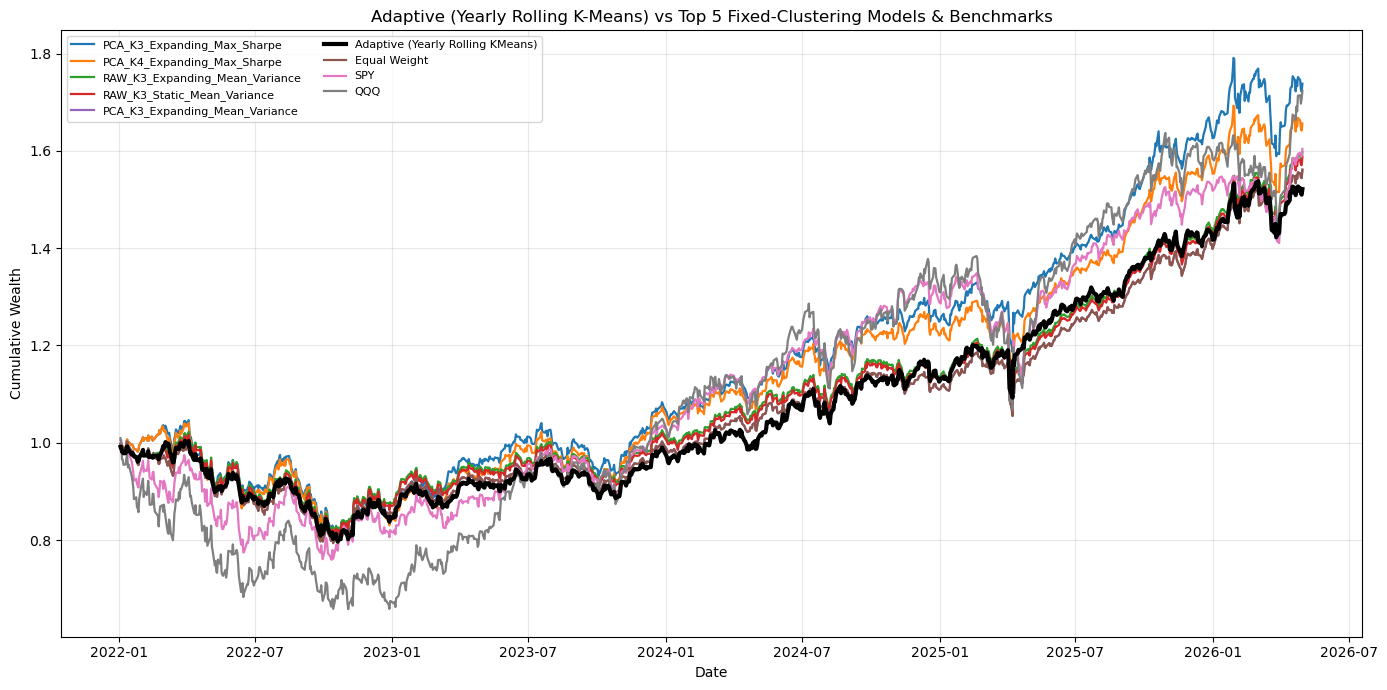

In [22]:
# ============================================================
# ADAPTIVE (YEARLY ROLLING K-MEANS) vs MAIN PERFORMANCE TABLE
# ============================================================
#
# Inserisce la strategia realmente adattiva (rolling_kmeans_returns,
# che ogni anno seleziona la combinazione Feature/K/Strategy con
# lo Sharpe più alto dell'anno precedente) come riga aggiuntiva
# dentro alla tabella principale performance_df, in modo da vedere
# dove si posiziona rispetto a tutte le strategie a clustering fisso
# (PCA/RAW, K=2..5, Static/Expanding) e ai benchmark.
#
# Presuppone che siano già definiti nello script principale:
#   performance_df, rolling_kmeans_returns, returns_daily,
#   performance_metrics
# ============================================================

rf_adaptive        = returns_daily.loc[rolling_kmeans_returns.index, "BIL"]
benchmark_adaptive = returns_daily.loc[rolling_kmeans_returns.index, "QQQ"]
metrics_adaptive   = performance_metrics(
    rolling_kmeans_returns, rf_adaptive, benchmark_returns=benchmark_adaptive
)

adaptive_row = pd.DataFrame([{
    "Features": "Adaptive",
    "Clusters": "-",
    "Strategy": "Yearly_Rolling_KMeans_Selected",
    **metrics_adaptive.to_dict()
}])

performance_df_with_adaptive = (
    pd.concat([performance_df, adaptive_row], ignore_index=True)
    .sort_values(by="Sharpe Ratio", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("MAIN PERFORMANCE TABLE + ADAPTIVE (YEARLY ROLLING K-MEANS) — NET OF 10 BPS TC")
print("=" * 80)
print(performance_df_with_adaptive.to_string(index=False))

adaptive_rank = performance_df_with_adaptive.index[
    performance_df_with_adaptive["Strategy"] == "Yearly_Rolling_KMeans_Selected"
][0] + 1
n_total = len(performance_df_with_adaptive)
print(f"\nLa strategia Adaptive si posiziona {adaptive_rank}° su {n_total} per Sharpe Ratio.")


# ============================================================
# CUMULATIVE WEALTH — ADAPTIVE vs TOP MODELS + BENCHMARKS
# ============================================================
#
# Confronto visivo: Adaptive vs le 5 migliori strategie a clustering
# fisso (per Sharpe) + i benchmark, sullo stesso periodo di test.
# ============================================================

top_n = 5
top_models = performance_df_with_adaptive[
    (performance_df_with_adaptive["Features"] != "Benchmark") &
    (performance_df_with_adaptive["Strategy"] != "Yearly_Rolling_KMeans_Selected")
].head(top_n)

plot_series_adaptive = {}

for _, row in top_models.iterrows():
    key = f"{row['Features']}_K{int(row['Clusters'])}_{row['Strategy']}"
    if key in all_returns:
        plot_series_adaptive[key] = all_returns[key]

plot_series_adaptive["Adaptive (Yearly Rolling KMeans)"] = rolling_kmeans_returns
plot_series_adaptive["Equal Weight"] = equal_weight_returns
plot_series_adaptive["SPY"]          = spy_returns
plot_series_adaptive["QQQ"]          = qqq_returns

common_idx_adaptive = rolling_kmeans_returns.index
cum_adaptive = pd.DataFrame({
    name: (1 + ret.loc[ret.index.intersection(common_idx_adaptive)]).cumprod()
    for name, ret in plot_series_adaptive.items()
}).dropna()

plt.figure(figsize=(14, 7))
for col in cum_adaptive.columns:
    if "Adaptive" in col:
        plt.plot(cum_adaptive.index, cum_adaptive[col],
                  linewidth=3.0, color="black", label=col, zorder=5)
    else:
        plt.plot(cum_adaptive.index, cum_adaptive[col], linewidth=1.6, label=col)
plt.title(f"Adaptive (Yearly Rolling K-Means) vs Top {top_n} Fixed-Clustering Models & Benchmarks")
plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/collar_payoff_qqq.png'

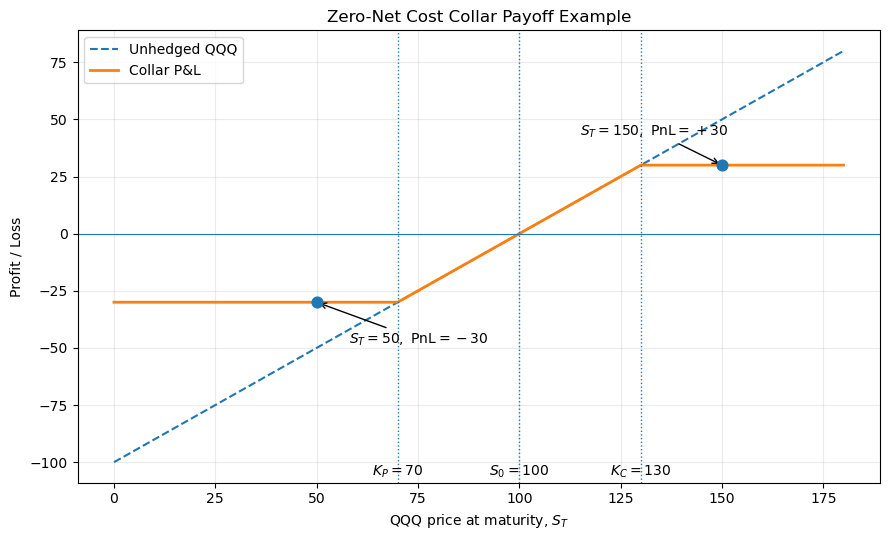

In [24]:

import numpy as np

import matplotlib.pyplot as plt

S0 = 100

Kp = 70

Kc = 130

ST = np.linspace(0, 180, 361)

# Zero-cost collar: put premium = call premium

pnl_underlying = ST - S0

pnl_collar = np.minimum(np.maximum(ST, Kp), Kc) - S0

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(ST, pnl_underlying, linestyle="--", label="Unhedged QQQ")

ax.plot(ST, pnl_collar, linewidth=2, label="Collar P&L")

ax.scatter([50, 150], [-30, 30], s=60, zorder=5)

ax.annotate(r"$S_T=50,\ \mathrm{PnL}=-30$",

            xy=(50, -30), xytext=(58, -48),

            arrowprops=dict(arrowstyle="->"))

ax.annotate(r"$S_T=150,\ \mathrm{PnL}=+30$",

            xy=(150, 30), xytext=(115, 43),

            arrowprops=dict(arrowstyle="->"))

ax.axhline(0, linewidth=0.8)

ax.axvline(Kp, linestyle=":", linewidth=1)

ax.axvline(S0, linestyle=":", linewidth=1)

ax.axvline(Kc, linestyle=":", linewidth=1)

ax.text(Kp, ax.get_ylim()[0] + 3, r"$K_P=70$", ha="center")

ax.text(S0, ax.get_ylim()[0] + 3, r"$S_0=100$", ha="center")

ax.text(Kc, ax.get_ylim()[0] + 3, r"$K_C=130$", ha="center")

ax.set_xlabel(r"QQQ price at maturity, $S_T$")

ax.set_ylabel("Profit / Loss")

ax.set_title("Zero-Net Cost Collar Payoff Example")

ax.legend()

ax.grid(True, alpha=0.25)

plt.tight_layout()

path = "/mnt/data/collar_payoff_qqq.png"

plt.savefig(path, dpi=300, bbox_inches="tight")

plt.show()

path